# 🛴 E-Scooter — Analyse descriptive
## Variable dépendante : `speed_kmh`

Ce notebook analyse le dataset filtré issu de la pipeline `build_clean_dataset.py`.  
Il couvre :
1. Chargement & aperçu des données  
2. Statistiques descriptives globales  
3. Distribution de la vitesse  
4. Vitesse × piétons (`n_pedestrians`)  
5. Vitesse × distance piéton (`distance_smooth_m`)  
6. Vitesse × largeur de route (`road_width_perp_m`)  
7. Vitesse × gyroscope / virage (`gyrz_deg_s`)  
8. Comparaison inter-trajets (`source`)  
9. Matrice de corrélation  
10. Vue synthétique — heatmap des moyennes par bin


## 1 · Imports & configuration

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Style global ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

PALETTE   = sns.color_palette("crest", as_cmap=False)
COLOR_SPD = "#2E86AB"   # bleu vitesse
COLOR_ACC = "#511A1E"   # rouge accent

DATASET_PATH = "/Volumes/My Passport/NEWMOB/clean_dataset.csv"   # ← adapter si besoin


## 2 · Chargement & aperçu

In [15]:
df = pd.read_csv(DATASET_PATH)

print(f"Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Trajets (source): {df['source'].nunique()}")
print(f"Frames uniques  : {df['frame'].nunique():,}")
print()
display(df.head(8))
print()
print("Types :")
display(df.dtypes.to_frame("dtype"))
print()
print("Valeurs manquantes :")
display(df.isna().sum().to_frame("n_missing"))


Dimensions     : 423,410 lignes × 60 colonnes
Trajets (source): 25
Frames uniques  : 5,413



/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/2939144066.py:1: DtypeWarning: Columns (23,40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


,source,frame,speed_kmh,gyrz_deg_s,n_vru_total,n_pedestrians,n_cyclists,n_escooters,prop_vru_pedestrian,prop_vru_cyclist,...,pct_stationary,pct_gait_standing,pct_gait_walking,pct_gait_running,pct_gait_unknown,pct_age_child,pct_age_adult,pct_age_elderly,pct_age_unknown,pct_unknown_interaction
0,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
4,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,3.56503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
5,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,3.56503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
6,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,3.56503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
7,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,3.56503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0



Types :


,dtype
source,object
frame,int64
speed_kmh,float64
gyrz_deg_s,float64
n_vru_total,int64
n_pedestrians,int64
n_cyclists,int64
n_escooters,int64
prop_vru_pedestrian,float64
prop_vru_cyclist,float64



Valeurs manquantes :


,n_missing
source,0
frame,0
speed_kmh,8691
gyrz_deg_s,8691
n_vru_total,0
n_pedestrians,0
n_cyclists,0
n_escooters,0
prop_vru_pedestrian,0
prop_vru_cyclist,0


## 3 · Statistiques descriptives globales

In [16]:
num_cols = ["speed_kmh", "n_pedestrians",
            "road_width_perp_m", "gyrz_deg_s"]

desc = df[num_cols].describe(percentiles=[.10, .25, .50, .75, .90]).T
desc["cv_%"] = (desc["std"] / desc["mean"] * 100).round(1)
display(desc.round(3))


,count,mean,std,min,10%,25%,50%,75%,90%,max,cv_%
speed_kmh,414719.0,14.336,7.407,2.018,7.208,8.778,11.693,18.939,27.470,33.998,51.7
n_pedestrians,423410.0,2.905,2.376,0.000,1.000,1.000,2.000,4.000,6.000,15.000,81.8
road_width_perp_m,405572.0,16.827,15.484,0.029,6.739,8.298,11.427,22.435,31.038,103.996,92.0
gyrz_deg_s,414719.0,0.230,10.962,-102.708,-13.391,-5.968,0.235,6.507,13.895,120.032,4757.2


## 4 · Distribution de la vitesse

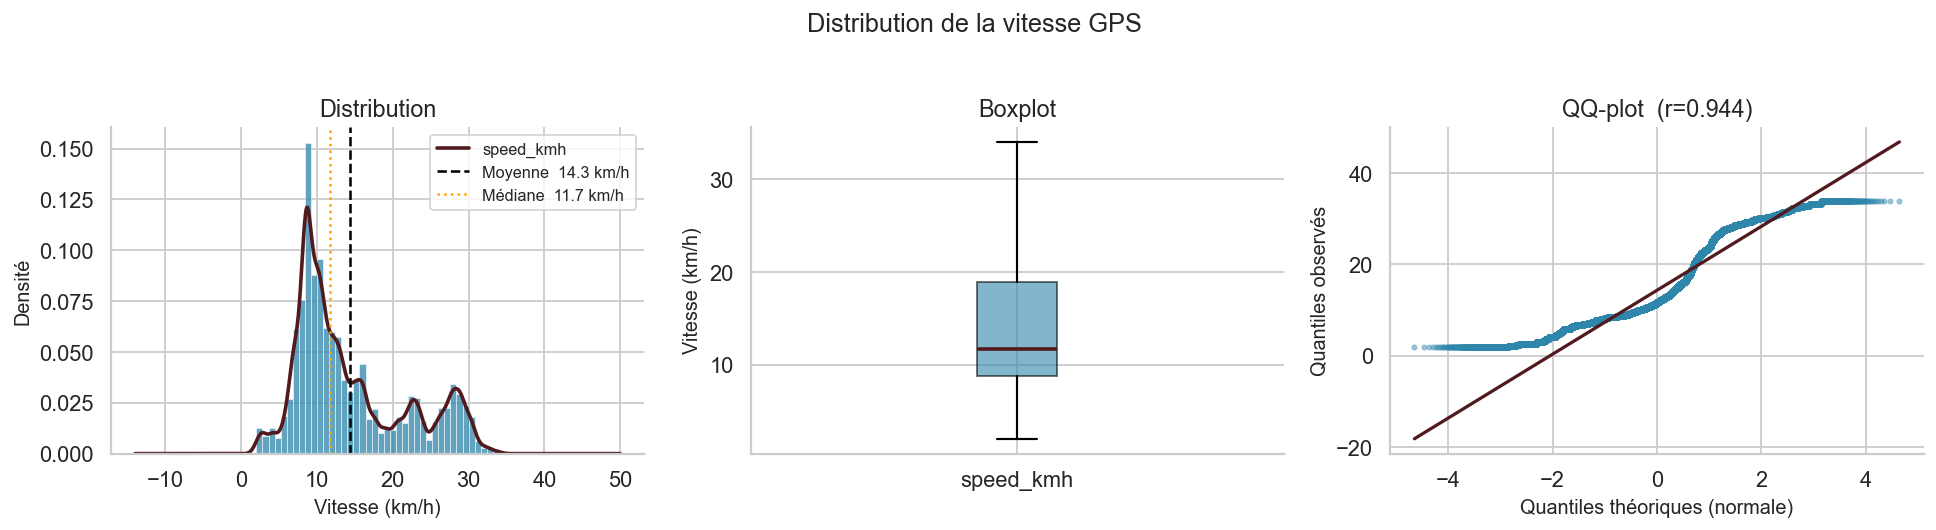

Shapiro-Wilk  W=0.8903  p=8.85e-51  → non-normale (α=0.05)
Skewness=0.844  |  Kurtosis=-0.446


In [17]:
spd = df["speed_kmh"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 4a — Histogramme + KDE
ax = axes[0]
ax.hist(spd, bins=40, color=COLOR_SPD, alpha=0.75, density=True, edgecolor="white", lw=0.4)
spd.plot.kde(ax=ax, color=COLOR_ACC, lw=2)
ax.axvline(spd.mean(),   color="black",  lw=1.4, ls="--", label=f"Moyenne  {spd.mean():.1f} km/h")
ax.axvline(spd.median(), color="orange", lw=1.4, ls=":",  label=f"Médiane  {spd.median():.1f} km/h")
ax.set_xlabel("Vitesse (km/h)")
ax.set_ylabel("Densité")
ax.set_title("Distribution")
ax.legend(fontsize=9)

# 4b — Boxplot
ax = axes[1]
ax.boxplot(spd, vert=True, patch_artist=True,
           boxprops=dict(facecolor=COLOR_SPD, alpha=0.6),
           medianprops=dict(color=COLOR_ACC, lw=2),
           whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
           flierprops=dict(marker=".", markersize=3, alpha=0.3))
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Boxplot")
ax.set_xticklabels(["speed_kmh"])

# 4c — QQ-plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(spd, dist="norm")
ax.scatter(osm, osr, s=6, alpha=0.4, color=COLOR_SPD)
ax.plot(osm, slope * np.array(osm) + intercept, color=COLOR_ACC, lw=1.8)
ax.set_xlabel("Quantiles théoriques (normale)")
ax.set_ylabel("Quantiles observés")
ax.set_title(f"QQ-plot  (r={r:.3f})")

plt.suptitle("Distribution de la vitesse GPS", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Test de normalité
stat, p = stats.shapiro(spd.sample(min(5000, len(spd)), random_state=42))
print(f"Shapiro-Wilk  W={stat:.4f}  p={p:.2e}  → {'non-normale' if p < 0.05 else 'normale'} (α=0.05)")
skew = spd.skew()
kurt = spd.kurtosis()
print(f"Skewness={skew:.3f}  |  Kurtosis={kurt:.3f}")


## 5 · Vitesse × nombre de piétons

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1893157584.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


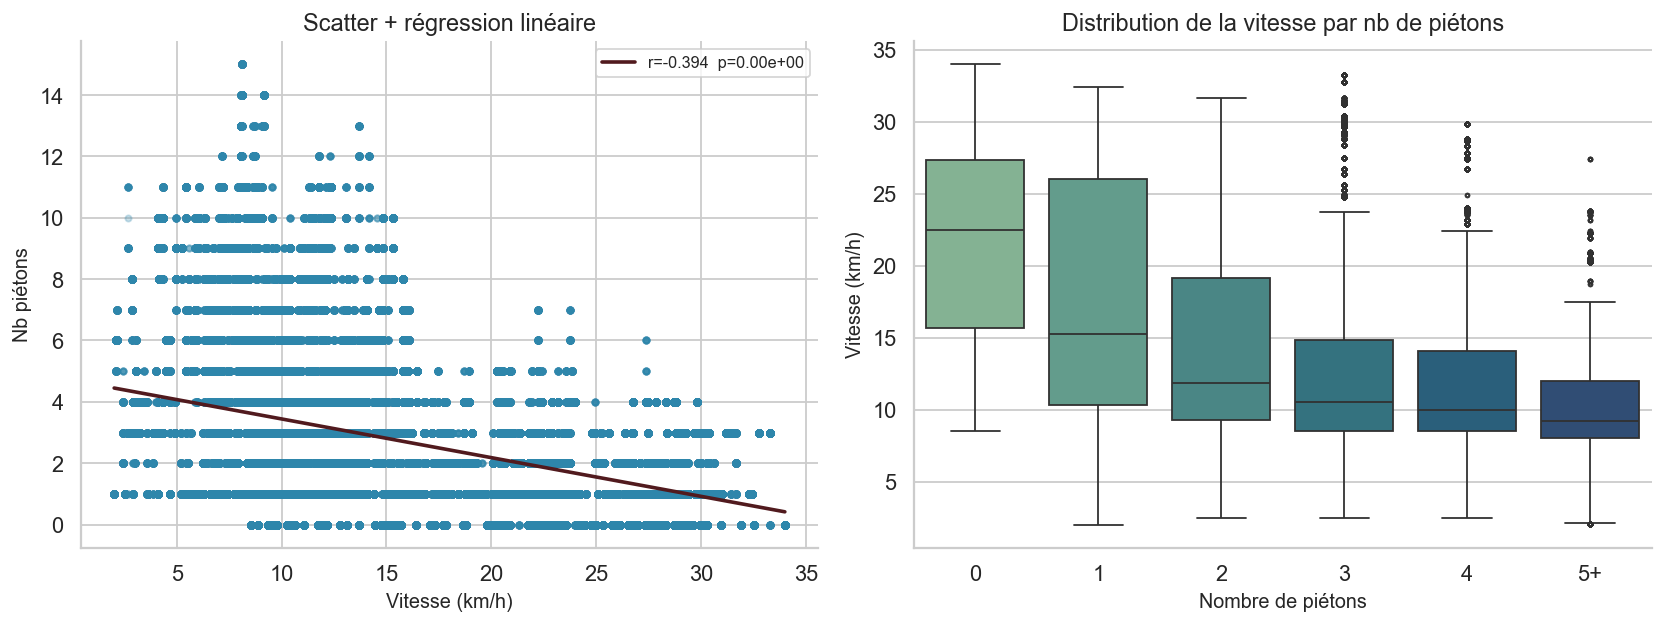

ANOVA one-way  F=6792.68  p=0.00e+00


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Données propres pour n_pedestrians
df_plot = df.copy()
df_plot["n_pedestrians_num"] = (
    pd.to_numeric(df_plot["n_pedestrians"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# 5a — Scatter + régression
ax = axes[0]
sub = df_plot[["speed_kmh", "n_pedestrians_num"]].dropna()

ax.scatter(
    sub["speed_kmh"],
    sub["n_pedestrians_num"],
    alpha=0.25,
    s=12,
    color=COLOR_SPD
)

if len(sub) >= 2:
    m, b, r, p, se = stats.linregress(sub["speed_kmh"], sub["n_pedestrians_num"])
    x_line = np.linspace(sub["speed_kmh"].min(), sub["speed_kmh"].max(), 200)
    ax.plot(
        x_line,
        m * x_line + b,
        color=COLOR_ACC,
        lw=2,
        label=f"r={r:.3f}  p={p:.2e}"
    )
    ax.legend(fontsize=9)

ax.set_xlabel("Vitesse (km/h)")
ax.set_ylabel("Nb piétons")
ax.set_title("Scatter + régression linéaire")

# 5b — Boxplot par nombre de piétons
ax = axes[1]
box_df = df_plot.dropna(subset=["n_pedestrians_num", "speed_kmh"]).copy()

box_df["n_ped_cat"] = (
    box_df["n_pedestrians_num"]
    .clip(upper=5)
    .astype(int)
    .astype(str)
)
box_df["n_ped_cat"] = box_df["n_ped_cat"].replace({"5": "5+"})

order = [str(i) for i in range(0, 5)] + ["5+"]
order = [o for o in order if o in box_df["n_ped_cat"].unique()]

sns.boxplot(
    data=box_df,
    x="n_ped_cat",
    y="speed_kmh",
    order=order,
    palette="crest",
    ax=ax,
    flierprops={"markersize": 2, "alpha": 0.3}
)

ax.set_xlabel("Nombre de piétons")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Distribution de la vitesse par nb de piétons")

plt.tight_layout()
plt.show()

# ANOVA one-way
anova_df = df_plot.dropna(subset=["n_pedestrians_num", "speed_kmh"]).copy()
anova_df["n_pedestrians_int"] = anova_df["n_pedestrians_num"].astype(int)

groups = [
    g["speed_kmh"].values
    for _, g in anova_df.groupby("n_pedestrians_int")
    if len(g) > 5
]

if len(groups) >= 2:
    F, p_anova = stats.f_oneway(*groups)
    print(f"ANOVA one-way  F={F:.2f}  p={p_anova:.2e}")
else:
    print("ANOVA impossible : pas assez de groupes avec > 5 observations.")

In [19]:
df['n_cyclists']

0         0
1         0
2         0
3         0
4         0
         ..
423405    0
423406    0
423407    0
423408    0
423409    0
Name: n_cyclists, Length: 423410, dtype: int64

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1410496502.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


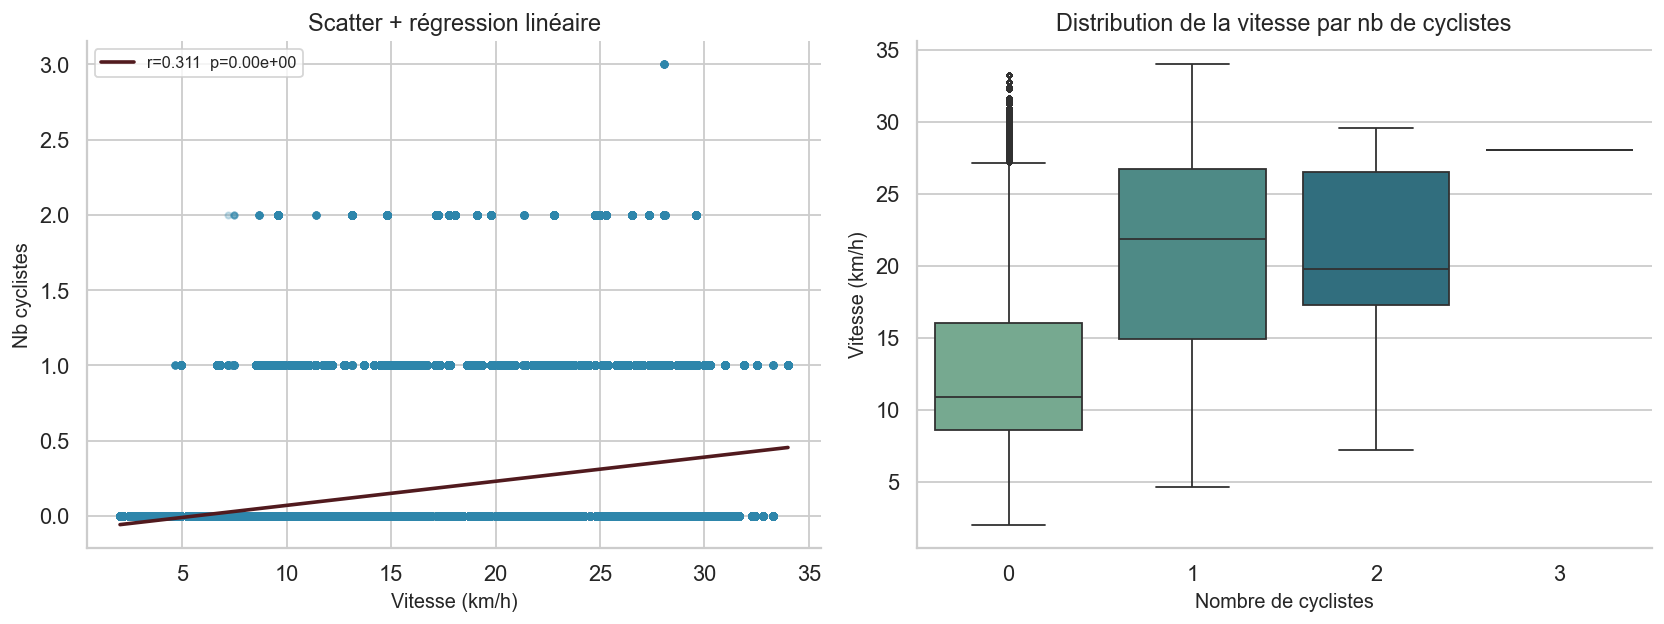

ANOVA one-way  F=15916.85  p=0.00e+00


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Données propres pour n_cyclists
df_plot = df.copy()
df_plot["n_cyclists_num"] = (
    pd.to_numeric(df_plot["n_cyclists"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# 5a — Scatter + régression
ax = axes[0]
sub = df_plot[["speed_kmh", "n_cyclists_num"]].dropna()

ax.scatter(
    sub["speed_kmh"],
    sub["n_cyclists_num"],
    alpha=0.25,
    s=12,
    color=COLOR_SPD
)

if len(sub) >= 2:
    m, b, r, p, se = stats.linregress(sub["speed_kmh"], sub["n_cyclists_num"])
    x_line = np.linspace(sub["speed_kmh"].min(), sub["speed_kmh"].max(), 200)
    ax.plot(
        x_line,
        m * x_line + b,
        color=COLOR_ACC,
        lw=2,
        label=f"r={r:.3f}  p={p:.2e}"
    )
    ax.legend(fontsize=9)

ax.set_xlabel("Vitesse (km/h)")
ax.set_ylabel("Nb cyclistes")
ax.set_title("Scatter + régression linéaire")

# 5b — Boxplot par nombre de cyclistes
ax = axes[1]
box_df = df_plot.dropna(subset=["n_cyclists_num", "speed_kmh"]).copy()

box_df["n_cyclists_cat"] = (
    box_df["n_cyclists_num"]
    .clip(upper=5)
    .astype(int)
    .astype(str)
)
box_df["n_cyclists_cat"] = box_df["n_cyclists_cat"].replace({"5": "5+"})

order = [str(i) for i in range(0, 5)] + ["5+"]
order = [o for o in order if o in box_df["n_cyclists_cat"].unique()]

sns.boxplot(
    data=box_df,
    x="n_cyclists_cat",
    y="speed_kmh",
    order=order,
    palette="crest",
    ax=ax,
    flierprops={"markersize": 2, "alpha": 0.3}
)

ax.set_xlabel("Nombre de cyclistes")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Distribution de la vitesse par nb de cyclistes")

plt.tight_layout()
plt.show()

# ANOVA one-way
anova_df = df_plot.dropna(subset=["n_cyclists_num", "speed_kmh"]).copy()
anova_df["n_cyclists_int"] = anova_df["n_cyclists_num"].astype(int)

groups = [
    g["speed_kmh"].values
    for _, g in anova_df.groupby("n_cyclists_int")
    if len(g) > 5
]

if len(groups) >= 2:
    F, p_anova = stats.f_oneway(*groups)
    print(f"ANOVA one-way  F={F:.2f}  p={p_anova:.2e}")
else:
    print("ANOVA impossible : pas assez de groupes avec > 5 observations.")

## 6 · Vitesse × distance au piéton

KeyError: "['distance_smooth_m'] not in index"

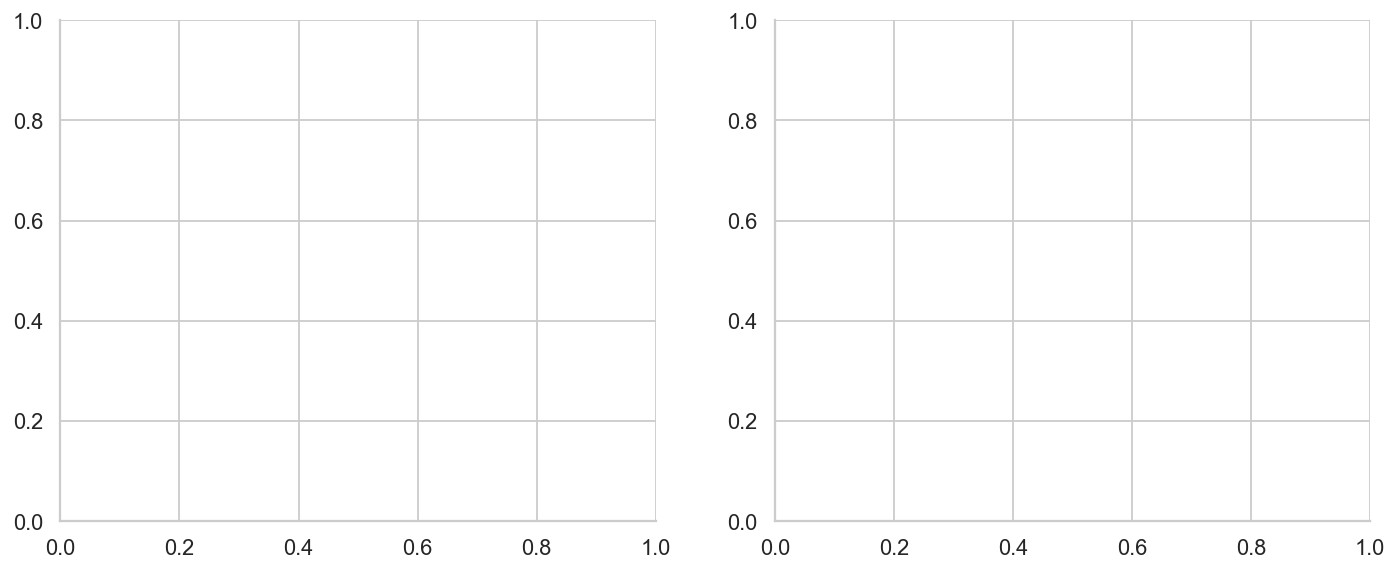

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sub = df[["speed_kmh", "distance_smooth_m"]].dropna()

# 6a — Hexbin
ax = axes[0]
hb = ax.hexbin(sub["distance_smooth_m"], sub["speed_kmh"],
               gridsize=35, cmap="Blues", mincnt=1)
plt.colorbar(hb, ax=ax, label="n observations")
ax.set_xlabel("Distance au piéton (m)")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Densité (hexbin)")

# 6b — Moyenne de vitesse par bin de distance
ax = axes[1]
bins_dist = np.arange(0, 15.5, 1)
sub["dist_bin"] = pd.cut(sub["distance_smooth_m"], bins_dist)
grp = sub.groupby("dist_bin")["speed_kmh"].agg(["mean", "sem"]).dropna()
centers = [iv.mid for iv in grp.index]
ax.bar(centers, grp["mean"], width=0.8, color=COLOR_SPD, alpha=0.75)
ax.errorbar(centers, grp["mean"], yerr=grp["sem"] * 1.96,
            fmt="none", color="black", capsize=3, lw=1.2)
ax.set_xlabel("Distance au piéton (m)")
ax.set_ylabel("Vitesse moyenne (km/h)")
ax.set_title("Vitesse moyenne par bin de distance (IC 95 %)")

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(sub["distance_smooth_m"], sub["speed_kmh"])
print(f"Pearson r={r:.3f}  p={p:.2e}")


## 7 · Vitesse × largeur de route

KeyboardInterrupt: 

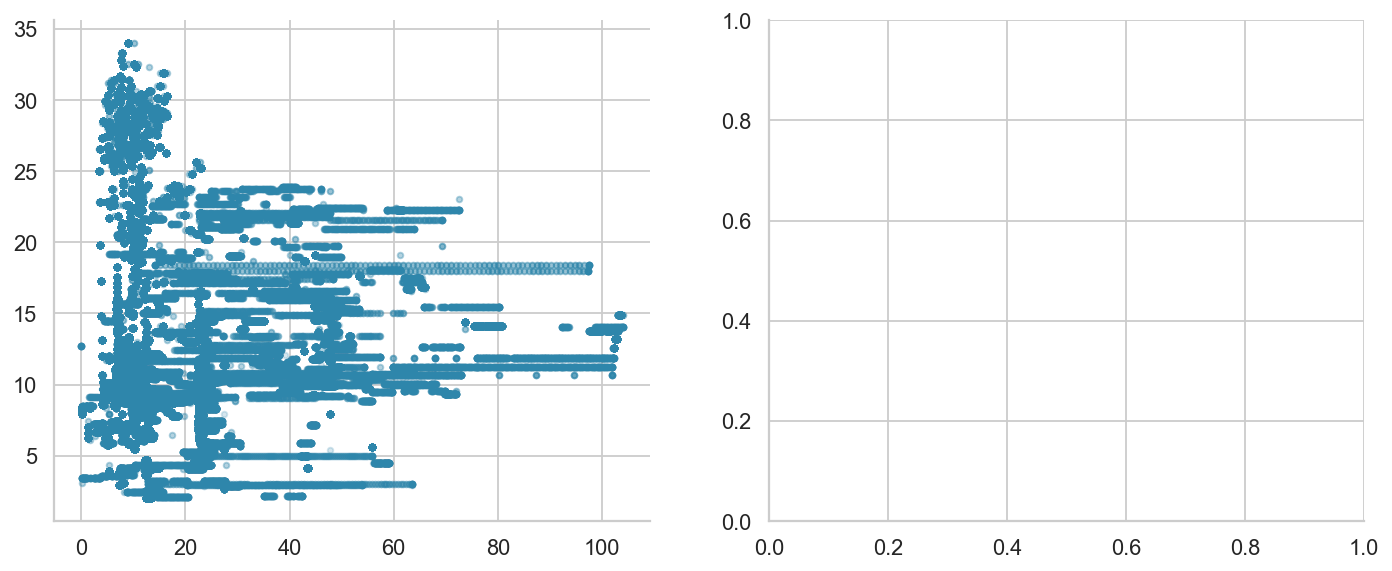

In [22]:
sub = df[["speed_kmh", "road_width_perp_m"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 7a — Scatter + LOWESS
ax = axes[0]
from statsmodels.nonparametric.smoothers_lowess import lowess
ax.scatter(sub["road_width_perp_m"], sub["speed_kmh"],
           alpha=0.2, s=10, color=COLOR_SPD)
lw_xy = lowess(sub["speed_kmh"], sub["road_width_perp_m"], frac=0.3)
ax.plot(lw_xy[:, 0], lw_xy[:, 1], color=COLOR_ACC, lw=2.5, label="LOWESS")
ax.set_xlabel("Largeur de route perpendiculaire (m)")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Scatter + LOWESS")
ax.legend(fontsize=9)

# 7b — Bins de largeur
ax = axes[1]
bins_w = [0, 4, 6, 8, 10, 15, 999]
labels_w = ["0–4", "4–6", "6–8", "8–10", "10–15", ">15"]
sub["width_bin"] = pd.cut(sub["road_width_perp_m"], bins=bins_w, labels=labels_w)
sns.violinplot(data=sub, x="width_bin", y="speed_kmh",
               palette="crest", ax=ax, inner="quartile",
               order=labels_w)
ax.set_xlabel("Largeur de route (m)")
ax.set_ylabel("Vitesse (km/h)")
ax.set_title("Distribution de vitesse par largeur de route")

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(sub["road_width_perp_m"], sub["speed_kmh"])
print(f"Pearson r={r:.3f}  p={p:.2e}")


## 9 · Comparaison inter-rider

Observations totales     : 423410
Riders uniques           : 15
Avec age renseigné       : 15
Avec experience renseigné: 15
Genres présents          : ['female' 'male']
       rider_id   genre   age  experience_num  nb_trajets  speed_mean
0   332t_vague2  female  29.0            3.00        57.0   12.666358
1   335t_vague2    male  55.0            3.00        24.0   25.102309
2   355t_vague1  female  37.0            1.50        68.0    9.730831
3   363t_vague2    male  27.0            3.00        50.0   11.244710
4   364t_vague2  female  53.0            3.00       108.0   10.999786
5   369t_vague2    male  21.0            0.75        75.0   18.984809
6   371t_vague3  female  53.0            0.25        28.0   10.423913
7   374t_vague2  female  23.0            1.50        52.0   13.784423
8   375t_vague1    male  49.0            0.25       120.0    7.347610
9   378t_vague1  female  30.0            0.25        14.0   10.805253
10  389t_vague2    male  21.0            3.00        70.0    

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/259983062.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="genre", y=ycol,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/259983062.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="genre", y=ycol,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/259983062.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="exp_bin", y=ycol,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/259983

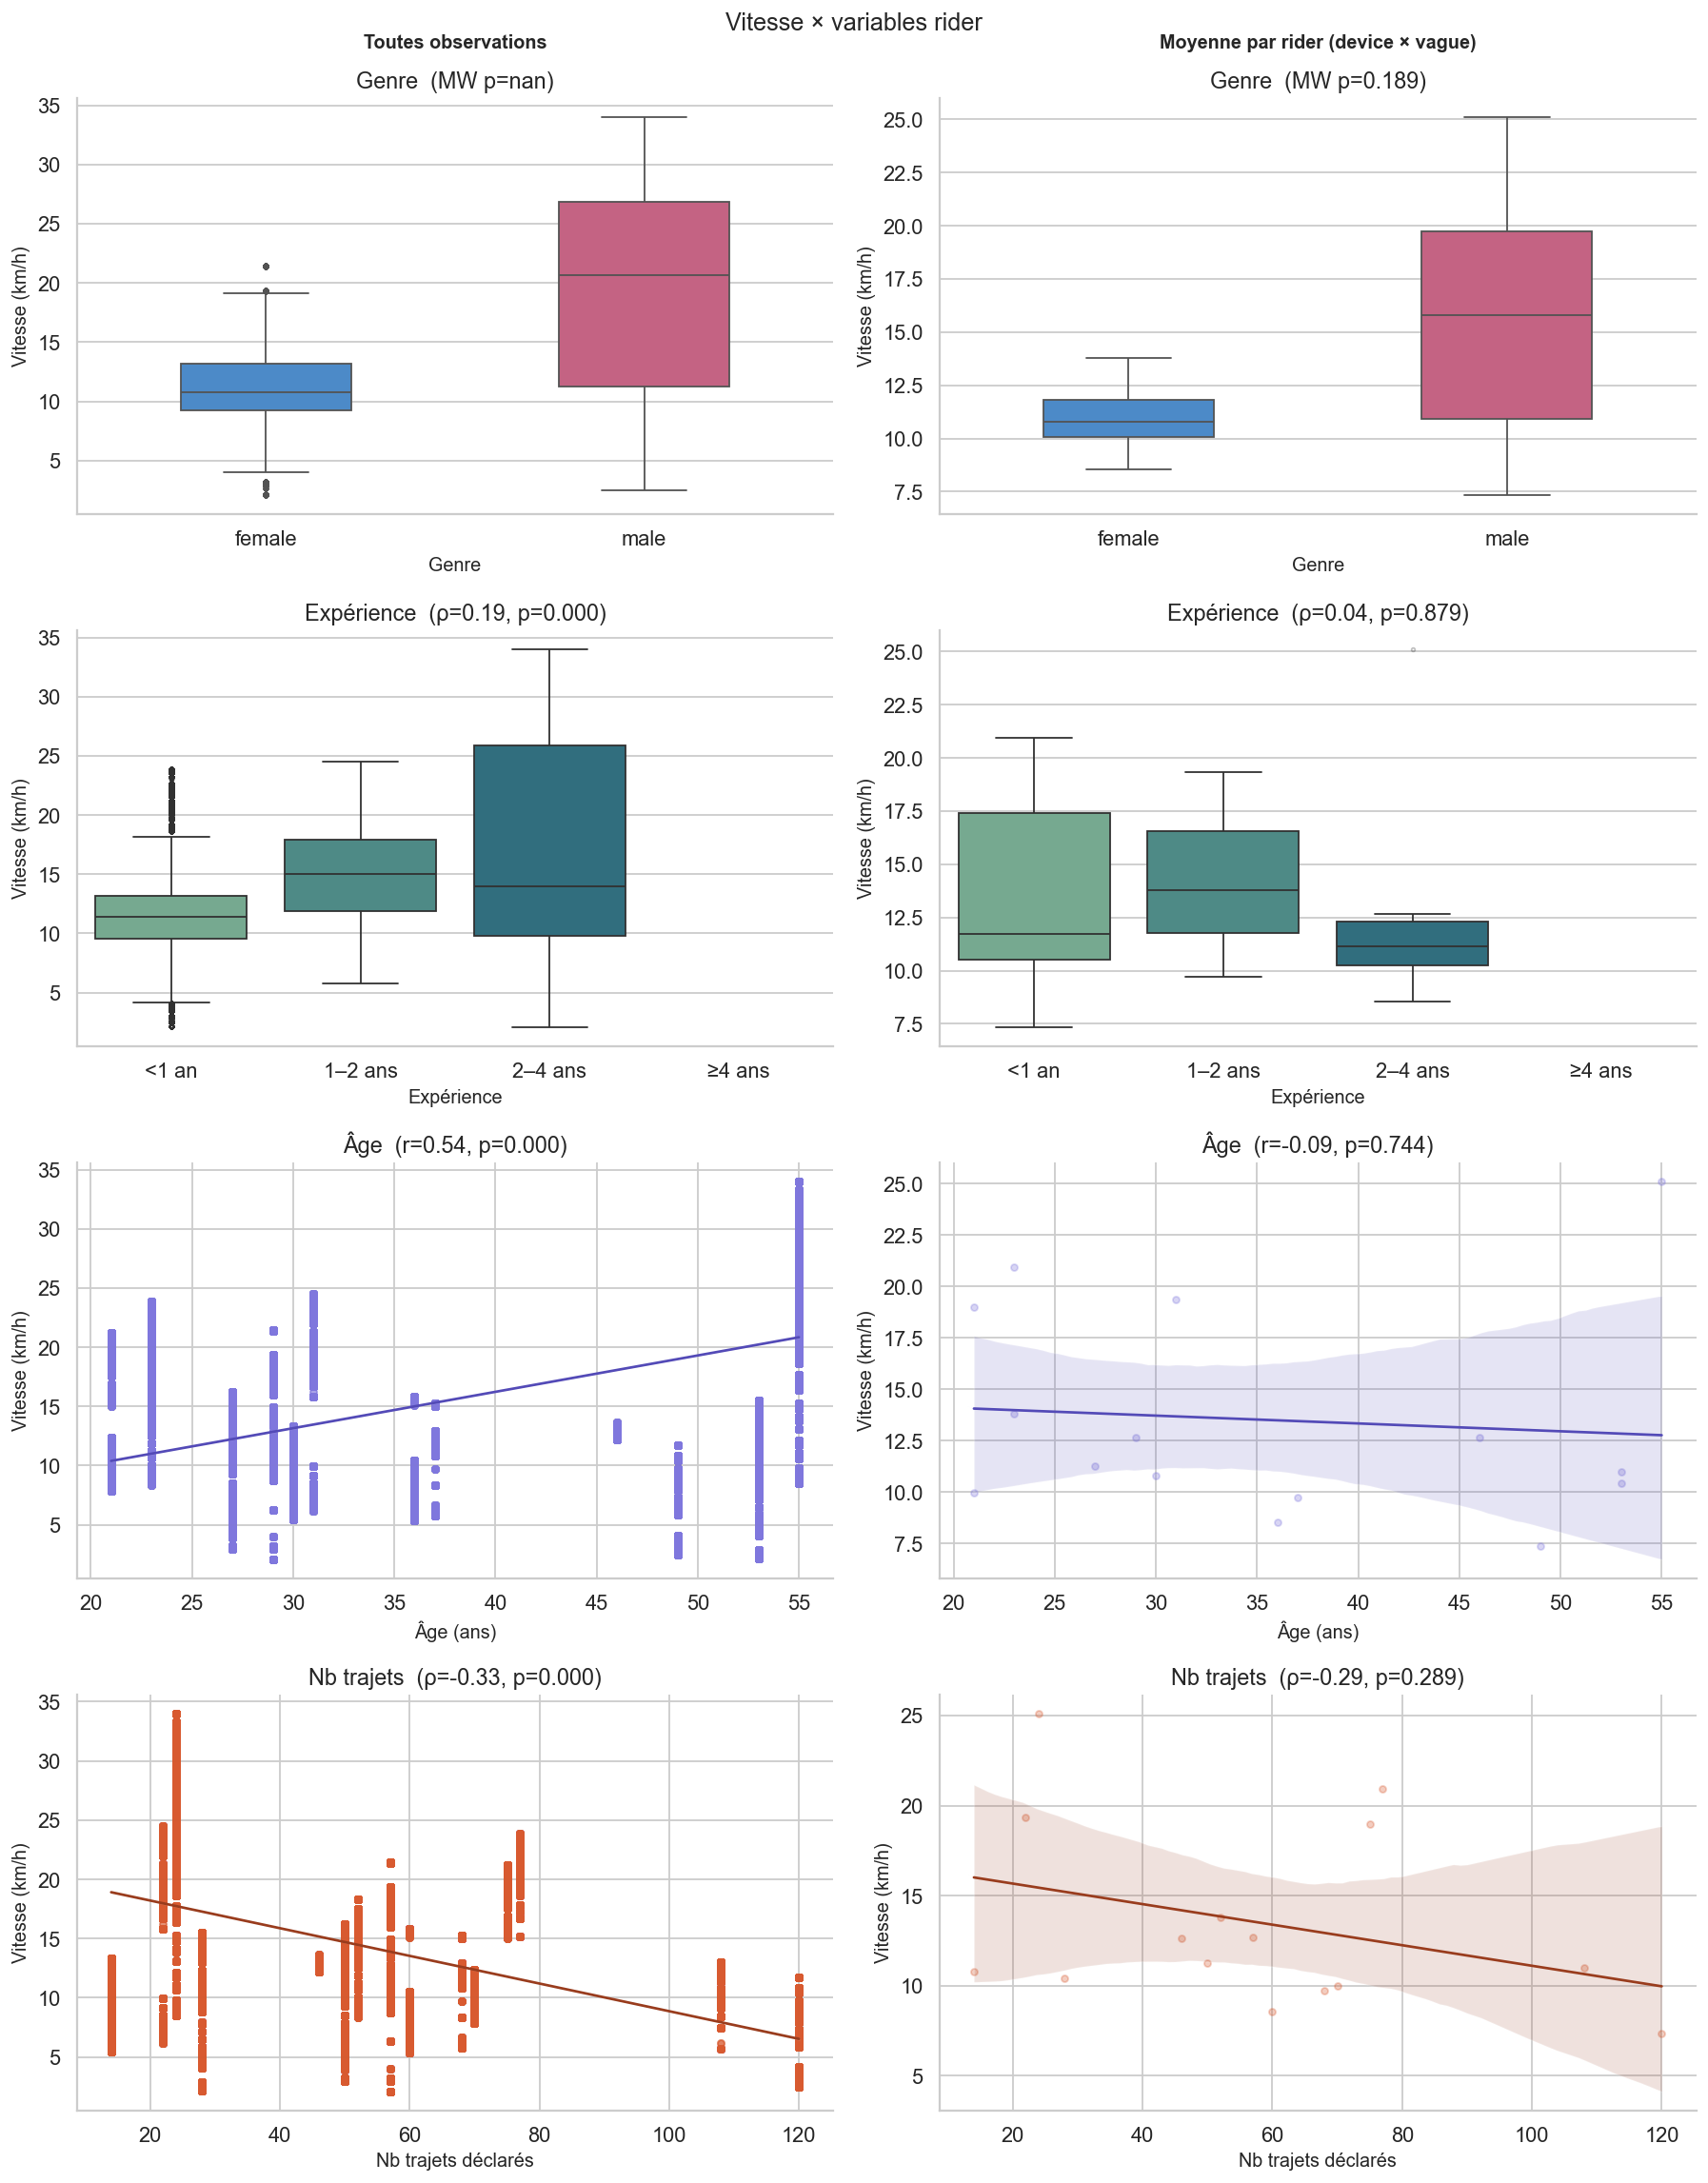


Corrélations de Spearman avec la vitesse
Variable             ρ (obs)   p (obs)   ρ (rider)   p (rider)
-----------------------------------------------------------------
  age               +0.395 ***     0.000     -0.202 ns       0.470
  experience_num    +0.192 ***     0.000     +0.043 ns       0.879
  nb_trajets        -0.328 ***     0.000     -0.293 ns       0.289
  distance_km       -0.099 ***     0.000     -0.096 ns       0.732


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ══════════════════════════════════════════════════════════════════════════════
# 0. Préparation des données rider
# ══════════════════════════════════════════════════════════════════════════════

exp_map = {
    "0.5-1": 0.75,
    "1-2":   1.5,
    ">2":    3.0,
    "<0.5":  0.25,
    "2-5":   3.5,
}

for col in ["age", "nb_trajets", "distance_km"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "experience" in df.columns:
    df["experience_num"] = df["experience"].map(exp_map)
    unmapped = df.loc[df["experience_num"].isna() & df["experience"].notna(),
                      "experience"].unique()
    if len(unmapped):
        print(f"⚠ Valeurs experience non mappées : {unmapped}")

# ── Niveau 1 : toutes les observations ───────────────────────────────────────
obs = df.copy()

# ── Niveau 2 : moyenne par rider (rider_id = device × vague) ─────────────────
rider_meta_cols = [c for c in ["genre", "age", "experience_num", "nb_trajets", "distance_km"]
                   if c in df.columns]

rider = (
    df.groupby(["rider_id"] + rider_meta_cols)["speed_kmh"]
    .mean()
    .reset_index()
    .rename(columns={"speed_kmh": "speed_mean"})
)

print(f"Observations totales     : {len(obs)}")
print(f"Riders uniques           : {rider['rider_id'].nunique()}")
print(f"Avec age renseigné       : {rider['age'].notna().sum()}")
print(f"Avec experience renseigné: {rider['experience_num'].notna().sum()}")
print(f"Genres présents          : {rider['genre'].dropna().unique()}")
print(rider[["rider_id", "genre", "age", "experience_num", "nb_trajets", "speed_mean"]].to_string())


# ══════════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════════

def mannwhitney_title(data, group_col, val_col, base_title):
    groups = [g[val_col].values for _, g in data.dropna(subset=[group_col]).groupby(group_col)]
    if len(groups) == 2 and all(len(g) >= 2 for g in groups):
        _, p = stats.mannwhitneyu(*groups, alternative="two-sided")
        return f"{base_title}  (MW p={p:.3f})"
    return base_title

def spearman_title(x, y, base_title):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return f"{base_title}  (n={len(sub)}, insuf.)"
    r, p = stats.spearmanr(sub["x"], sub["y"])
    return f"{base_title}  (ρ={r:.2f}, p={p:.3f})"

def pearson_title(x, y, base_title):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return f"{base_title}  (n={len(sub)}, insuf.)"
    r, p = stats.pearsonr(sub["x"], sub["y"])
    return f"{base_title}  (r={r:.2f}, p={p:.3f})"


# ══════════════════════════════════════════════════════════════════════════════
# Plots — 4 variables × 2 niveaux = 8 axes (4 lignes × 2 colonnes)
# Colonne gauche  : toutes les observations
# Colonne droite  : moyenne par rider (rider_id)
# ══════════════════════════════════════════════════════════════════════════════

unique_genres = obs["genre"].dropna().unique()
palette_genre = dict(zip(sorted(unique_genres), ["#378ADD", "#D4537E", "#1D9E75", "#D85A30"]))

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle("Vitesse × variables rider", fontsize=14)

col_titles = ["Toutes observations", "Moyenne par rider (device × vague)"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(title, xy=(0.5, 1.12), xycoords="axes fraction",
                ha="center", fontsize=11, fontweight="bold")

# ── Ligne 1 : Genre ───────────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[0],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sns.boxplot(data=data, x="genre", y=ycol,
                palette=palette_genre, width=0.45,
                flierprops={"markersize": 2, "alpha": 0.3}, ax=ax)
    ax.set_title(mannwhitney_title(data, "genre", ycol, "Genre"))
    ax.set_xlabel("Genre"); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 2 : Expérience ──────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[1],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sub = data.dropna(subset=["experience_num", ycol]).copy()
    if len(sub) >= 2:
        sub["exp_bin"] = pd.cut(sub["experience_num"],
                                bins=[0, 1, 2, 4, 99],
                                labels=["<1 an", "1–2 ans", "2–4 ans", "≥4 ans"],
                                right=False)
        sns.boxplot(data=sub, x="exp_bin", y=ycol,
                    palette="crest", ax=ax,
                    flierprops={"markersize": 2, "alpha": 0.3})
        ax.set_title(spearman_title(sub["experience_num"], sub[ycol], "Expérience"))
    else:
        ax.set_title(f"Expérience (n={len(sub)}, insuf.)")
    ax.set_xlabel("Expérience"); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 3 : Âge ─────────────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[2],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sub = data[["age", ycol]].dropna()
    if len(sub) >= 2:
        sns.regplot(data=sub, x="age", y=ycol, ax=ax,
                    scatter_kws={"alpha": 0.3, "s": 15, "color": "#7F77DD"},
                    line_kws={"color": "#534AB7", "lw": 1.5})
        ax.set_title(pearson_title(sub["age"], sub[ycol], "Âge"))
    else:
        ax.set_title(f"Âge (n={len(sub)}, insuf.)")
    ax.set_xlabel("Âge (ans)"); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 4 : Nb trajets ──────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[3],
                           [obs, rider],
                           ["speed_kmh", "speed_mean"]):
    sub = data[["nb_trajets", ycol]].dropna()
    if len(sub) >= 2:
        sns.regplot(data=sub, x="nb_trajets", y=ycol, ax=ax,
                    scatter_kws={"alpha": 0.3, "s": 15, "color": "#D85A30"},
                    line_kws={"color": "#993C1D", "lw": 1.5})
        ax.set_title(spearman_title(sub["nb_trajets"], sub[ycol], "Nb trajets"))
    else:
        ax.set_title(f"Nb trajets (n={len(sub)}, insuf.)")
    ax.set_xlabel("Nb trajets déclarés"); ax.set_ylabel("Vitesse (km/h)")

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Tableau de corrélations — les deux niveaux côte à côte
# ══════════════════════════════════════════════════════════════════════════════
print("\nCorrélations de Spearman avec la vitesse")
print(f"{'Variable':18s}  {'ρ (obs)':>8}  {'p (obs)':>8}  {'ρ (rider)':>10}  {'p (rider)':>10}")
print("-" * 65)

for v in ["age", "experience_num", "nb_trajets", "distance_km"]:
    results = []
    for data, ycol in [(obs, "speed_kmh"), (rider, "speed_mean")]:
        if v not in data.columns:
            results.append(("n/a", "n/a"))
            continue
        sub = data[[v, ycol]].dropna()
        if len(sub) < 2:
            results.append((f"n={len(sub)}", "—"))
            continue
        r, p = stats.spearmanr(sub[v], sub[ycol])
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        results.append((f"{r:+.3f} {sig}", f"{p:.3f}"))
    print(f"  {v:16s}  {results[0][0]:>10}  {results[0][1]:>8}  {results[1][0]:>12}  {results[1][1]:>10}")

✔ Colonnes temporelles présentes

Observations totales  : 423410
Trajets uniques       : 25
Distribution time_of_day (trajets) :
time_of_day
Morning      14
Afternoon     9
Night         1
Evening       1

Weekend vs weekday (trajets) :
is_weekend
False    21
True      4


/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/2754825902.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="Jour", y=ycol, order=order,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/2754825902.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x="Jour", y=ycol, order=order,
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/2754825902.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data.dropna(subset=["time_of_day", ycol]),
/var/folders/y0/0nrj3m412p97818

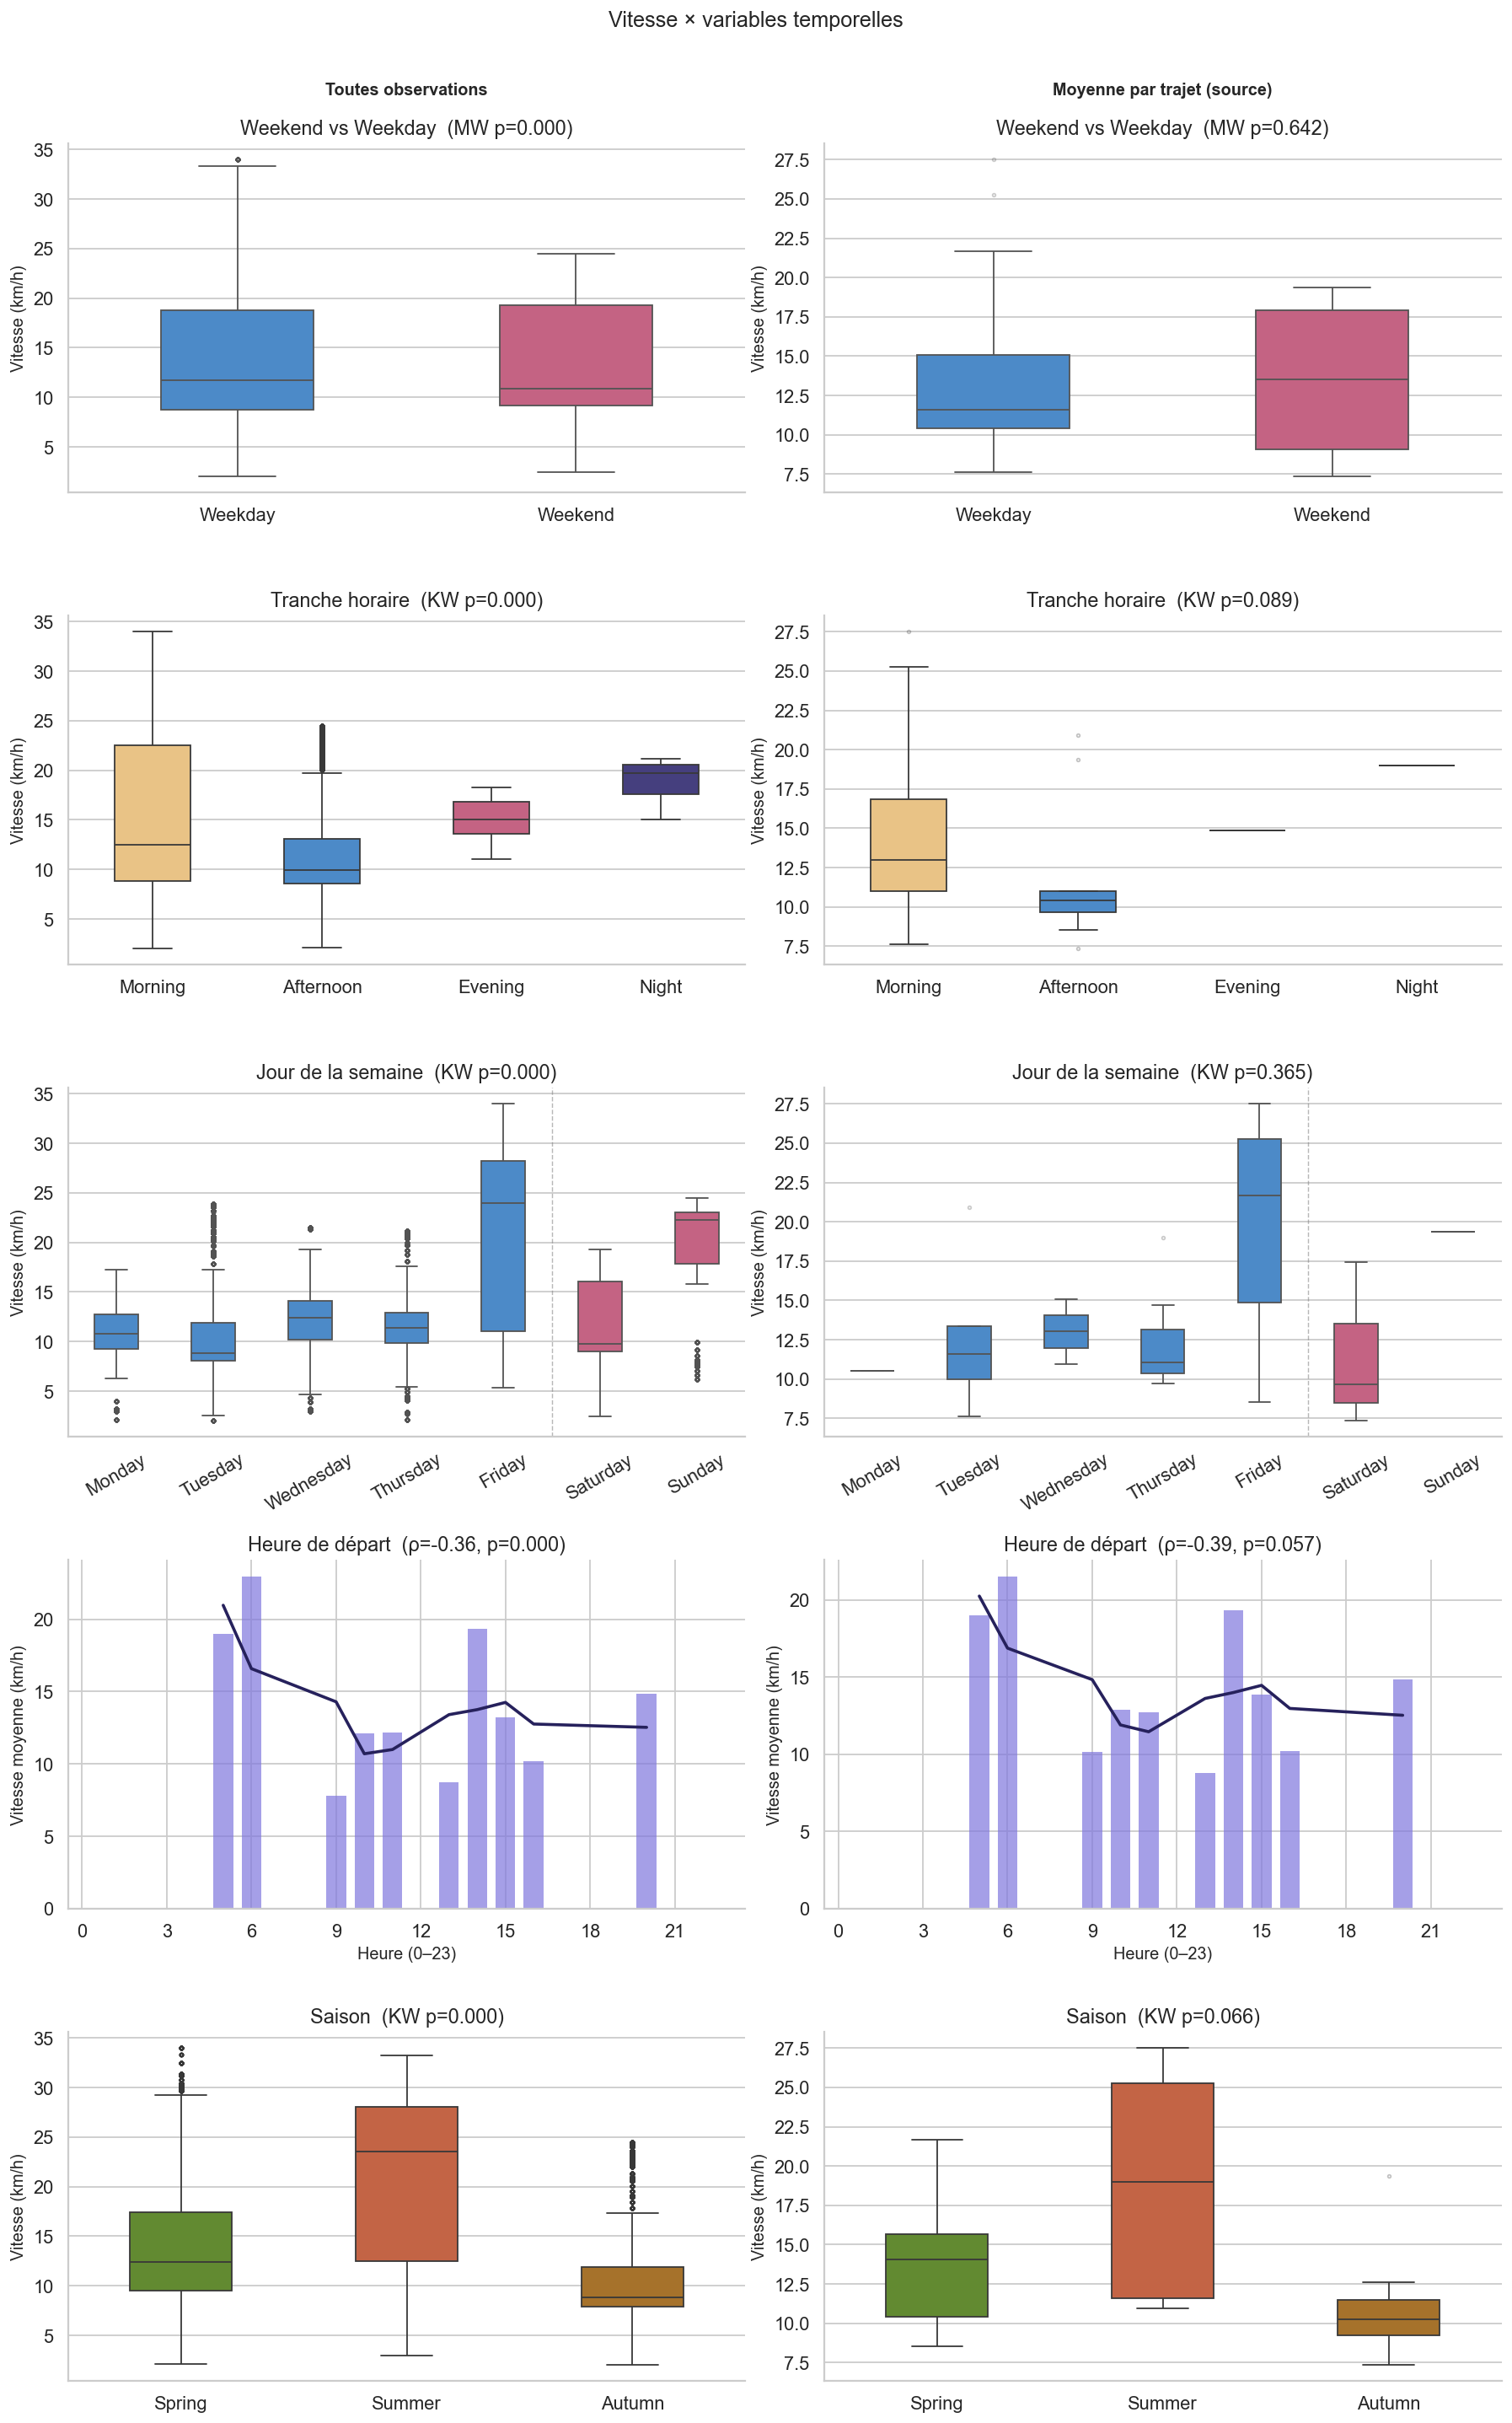

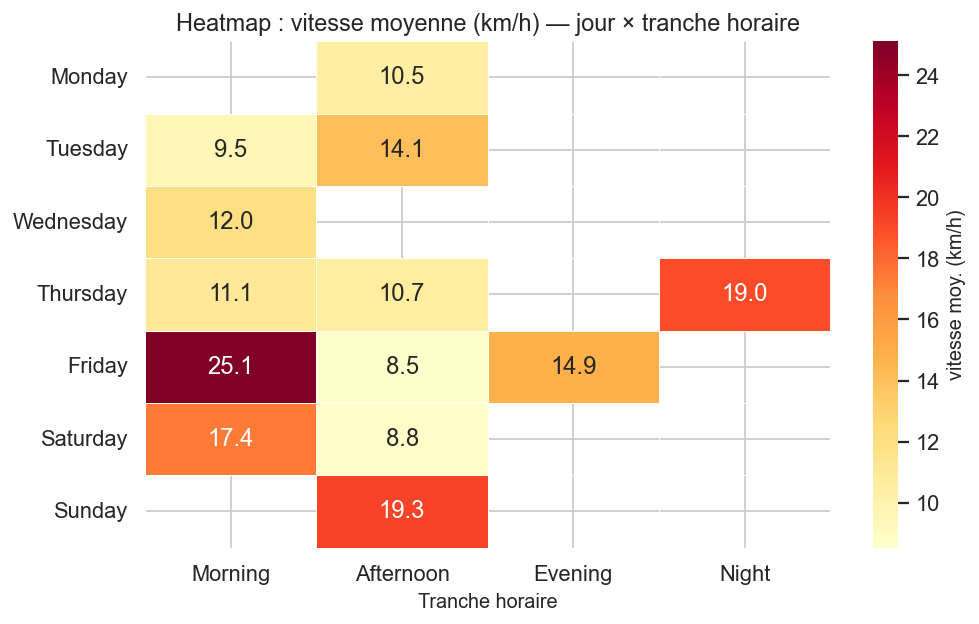


Tests statistiques — Vitesse × variables temporelles

Variable                        stat (obs)   p (obs)   stat (trip)    p (trip)
--------------------------------------------------------------------------------
  Weekday/Weekend  (MW)         7590563969.0 ***     0.000         49.0 ns       0.642
  Tranche horaire  (KW)          22872.9 ***     0.000         36.0 ns       0.095
  Jour semaine     (KW)         114726.0 ***     0.000          4.3 ns       0.365
  Saison           (KW)         110174.2 ***     0.000          5.4 ns       0.066

Variable                           ρ (obs)   p (obs)      ρ (trip)    p (trip)
--------------------------------------------------------------------------------
  Heure départ     (Sp)           -0.360 ***     0.000       -0.385 ns       0.057

Légende significance : *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05
Tests : MW = Mann-Whitney, KW = Kruskal-Wallis, Sp = Spearman


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Vitesse × variables temporelles
# ══════════════════════════════════════════════════════════════════════════════
# Prérequis : df chargé avec les colonnes issues de build_clean_dataset.py
# Nouvelles colonnes utilisées :
#   hour, day_of_week, day_name, is_weekend, time_of_day, month, season

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Vérification des colonnes temporelles disponibles ────────────────────────
TEMPORAL_COLS = ["hour", "day_of_week", "day_name", "is_weekend",
                 "time_of_day", "month", "season"]
missing = [c for c in TEMPORAL_COLS if c not in df.columns]
if missing:
    print(f"⚠ Colonnes temporelles manquantes : {missing}")
    print("  → Relancer build_clean_dataset.py pour les générer.")
else:
    print("✔ Colonnes temporelles présentes")

# ── Conversion de types ───────────────────────────────────────────────────────
for col in ["hour", "day_of_week", "month"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Niveau 1 : toutes les observations ───────────────────────────────────────
obs = df.copy()

# ── Niveau 2 : moyenne par trajet (source = un trajet e-scooter) ──────────────
# On utilise source comme unité d'agrégation car chaque trajet a un seul
# timestamp (is_weekend, time_of_day, etc. sont identiques par source).
temporal_meta = [c for c in TEMPORAL_COLS if c in df.columns]

trip = (
    df.groupby(["source"] + temporal_meta)["speed_kmh"]
    .mean()
    .reset_index()
    .rename(columns={"speed_kmh": "speed_mean"})
)

print(f"\nObservations totales  : {len(obs)}")
print(f"Trajets uniques       : {trip['source'].nunique()}")
if "time_of_day" in trip.columns:
    print(f"Distribution time_of_day (trajets) :\n"
          f"{trip['time_of_day'].value_counts(dropna=False).to_string()}")
if "is_weekend" in trip.columns:
    print(f"\nWeekend vs weekday (trajets) :\n"
          f"{trip['is_weekend'].value_counts(dropna=False).to_string()}")


# ══════════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════════

def mannwhitney_title(data, group_col, val_col, base_title):
    groups = [g[val_col].dropna().values
              for _, g in data.dropna(subset=[group_col, val_col]).groupby(group_col)]
    if len(groups) == 2 and all(len(g) >= 2 for g in groups):
        _, p = stats.mannwhitneyu(*groups, alternative="two-sided")
        return f"{base_title}  (MW p={p:.3f})"
    return base_title

def kruskal_title(data, group_col, val_col, base_title):
    groups = [g[val_col].dropna().values
              for _, g in data.dropna(subset=[group_col, val_col]).groupby(group_col)]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        _, p = stats.kruskal(*groups)
        return f"{base_title}  (KW p={p:.3f})"
    return base_title

def spearman_title(x, y, base_title):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return f"{base_title}  (n={len(sub)}, insuf.)"
    r, p = stats.spearmanr(sub["x"], sub["y"])
    return f"{base_title}  (ρ={r:.2f}, p={p:.3f})"


# ══════════════════════════════════════════════════════════════════════════════
# Palettes fixes
# ══════════════════════════════════════════════════════════════════════════════

# Ordre logique des tranches horaires
TOD_ORDER = ["Morning", "Afternoon", "Evening", "Night"]
TOD_COLORS = {
    "Morning":   "#FAC775",  # amber clair
    "Afternoon": "#378ADD",  # bleu
    "Evening":   "#D4537E",  # rose
    "Night":     "#3C3489",  # violet foncé
}

# Ordre logique des jours (lundi en premier)
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DOW_COLORS = (
    ["#378ADD"] * 5      # Lun–Ven : bleu
    + ["#D4537E"] * 2    # Sam–Dim : rose
)

SEASON_ORDER  = ["Spring", "Summer", "Autumn", "Winter"]
SEASON_COLORS = {"Spring": "#639922", "Summer": "#D85A30",
                 "Autumn": "#BA7517", "Winter": "#185FA5"}

WEEKEND_COLORS = {False: "#378ADD", True: "#D4537E"}


# ══════════════════════════════════════════════════════════════════════════════
# Figure principale — 5 lignes × 2 colonnes
# Col gauche : toutes les observations | Col droite : moyenne par trajet
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
fig.suptitle("Vitesse × variables temporelles", fontsize=14, y=1.005)

col_titles = ["Toutes observations", "Moyenne par trajet (source)"]
for ax, title in zip(axes[0], col_titles):
    ax.annotate(title, xy=(0.5, 1.14), xycoords="axes fraction",
                ha="center", fontsize=11, fontweight="bold")

fp = {"markersize": 2, "alpha": 0.3}   # flierprops communs

# ── Ligne 0 : Weekend vs Weekday ──────────────────────────────────────────────
for ax, data, ycol in zip(axes[0], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "is_weekend" not in data.columns:
        ax.set_visible(False); continue
    d = data.dropna(subset=["is_weekend", ycol]).copy()
    d["Jour"] = d["is_weekend"].map({True: "Weekend", False: "Weekday"})
    order = ["Weekday", "Weekend"]
    palette = {"Weekday": "#378ADD", "Weekend": "#D4537E"}
    sns.boxplot(data=d, x="Jour", y=ycol, order=order,
                palette=palette, width=0.45, flierprops=fp, ax=ax)
    title = mannwhitney_title(d, "Jour", ycol, "Weekend vs Weekday")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 1 : Time of day ─────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[1], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "time_of_day" not in data.columns:
        ax.set_visible(False); continue
    present = [t for t in TOD_ORDER if t in data["time_of_day"].values]
    colors  = [TOD_COLORS[t] for t in present]
    sns.boxplot(data=data.dropna(subset=["time_of_day", ycol]),
                x="time_of_day", y=ycol, order=present,
                palette=dict(zip(present, colors)), width=0.45, flierprops=fp, ax=ax)
    title = kruskal_title(data, "time_of_day", ycol, "Tranche horaire")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Vitesse (km/h)")

# ── Ligne 2 : Jour de la semaine ─────────────────────────────────────────────
for ax, data, ycol in zip(axes[2], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "day_name" not in data.columns:
        ax.set_visible(False); continue
    present = [d for d in DOW_ORDER if d in data["day_name"].values]
    colors  = [DOW_COLORS[DOW_ORDER.index(d)] for d in present]
    sns.boxplot(data=data.dropna(subset=["day_name", ycol]),
                x="day_name", y=ycol, order=present,
                palette=dict(zip(present, colors)), width=0.45, flierprops=fp, ax=ax)
    title = kruskal_title(data, "day_name", ycol, "Jour de la semaine")
    ax.set_title(title); ax.set_xlabel("")
    ax.set_ylabel("Vitesse (km/h)")
    ax.tick_params(axis="x", rotation=30)
    # Séparer visuellement weekend
    n_present_weekdays = sum(1 for d in present if d in DOW_ORDER[:5])
    if n_present_weekdays > 0 and any(d in present for d in DOW_ORDER[5:]):
        ax.axvline(n_present_weekdays - 0.5, color="#888", lw=0.8,
                   ls="--", alpha=0.6, label="weekend →")

# ── Ligne 3 : Heure de la journée (scatter + régression) ─────────────────────
for ax, data, ycol in zip(axes[3], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "hour" not in data.columns:
        ax.set_visible(False); continue
    sub = data[["hour", ycol]].dropna()
    if len(sub) >= 2:
        # Boîtes par heure (groupby)
        hourly = data.dropna(subset=["hour", ycol]).copy()
        hourly["hour_int"] = hourly["hour"].astype(int)
        means = hourly.groupby("hour_int")[ycol].mean()
        ax.bar(means.index, means.values, width=0.7,
               color="#7F77DD", alpha=0.7, linewidth=0)
        # Courbe lissée (rolling)
        smooth = means.sort_index().rolling(window=3, center=True, min_periods=1).mean()
        ax.plot(smooth.index, smooth.values, color="#26215C", lw=2)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax.set_xlim(-0.5, 23.5)
        title = spearman_title(sub["hour"], sub[ycol], "Heure de départ")
        ax.set_title(title)
    else:
        ax.set_title(f"Heure (n={len(sub)}, insuf.)")
    ax.set_xlabel("Heure (0–23)"); ax.set_ylabel("Vitesse moyenne (km/h)")

# ── Ligne 4 : Saison ──────────────────────────────────────────────────────────
for ax, data, ycol in zip(axes[4], [obs, trip], ["speed_kmh", "speed_mean"]):
    if "season" not in data.columns:
        ax.set_visible(False); continue
    present = [s for s in SEASON_ORDER if s in data["season"].values]
    colors  = [SEASON_COLORS[s] for s in present]
    sns.boxplot(data=data.dropna(subset=["season", ycol]),
                x="season", y=ycol, order=present,
                palette=dict(zip(present, colors)), width=0.45, flierprops=fp, ax=ax)
    title = kruskal_title(data, "season", ycol, "Saison")
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Vitesse (km/h)")

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Heatmap : vitesse moyenne par jour × tranche horaire
# ══════════════════════════════════════════════════════════════════════════════

if "day_name" in obs.columns and "time_of_day" in obs.columns:
    heatmap_data = (
        obs.dropna(subset=["day_name", "time_of_day", "speed_kmh"])
        .groupby(["day_name", "time_of_day"])["speed_kmh"]
        .mean()
        .unstack("time_of_day")
        .reindex(index=DOW_ORDER, columns=TOD_ORDER)
    )
    if not heatmap_data.empty:
        fig2, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd",
                    linewidths=0.3, cbar_kws={"label": "vitesse moy. (km/h)"},
                    ax=ax)
        ax.set_title("Heatmap : vitesse moyenne (km/h) — jour × tranche horaire")
        ax.set_xlabel("Tranche horaire"); ax.set_ylabel("")
        plt.tight_layout()
        plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Tableau de corrélations / tests — variables temporelles
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("Tests statistiques — Vitesse × variables temporelles")
print("=" * 70)

# Variables catégorielles : test de Kruskal-Wallis (ou Mann-Whitney si 2 groupes)
cat_vars = [
    ("is_weekend",  "Weekday/Weekend  (MW)"),
    ("time_of_day", "Tranche horaire  (KW)"),
    ("day_name",    "Jour semaine     (KW)"),
    ("season",      "Saison           (KW)"),
]

print(f"\n{'Variable':30s}  {'stat (obs)':>10}  {'p (obs)':>8}  {'stat (trip)':>12}  {'p (trip)':>10}")
print("-" * 80)

for col, label in cat_vars:
    results = []
    for data, ycol in [(obs, "speed_kmh"), (trip, "speed_mean")]:
        if col not in data.columns:
            results.append(("n/a", "n/a")); continue
        groups = [g[ycol].dropna().values
                  for _, g in data.dropna(subset=[col, ycol]).groupby(col)]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) < 2:
            results.append((f"n<2", "—")); continue
        if len(groups) == 2:
            stat, p = stats.mannwhitneyu(*groups, alternative="two-sided")
            test_name = "MW"
        else:
            stat, p = stats.kruskal(*groups)
            test_name = "KW"
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        results.append((f"{stat:.1f} {sig}", f"{p:.3f}"))
    print(f"  {label:28s}  {results[0][0]:>12}  {results[0][1]:>8}  "
          f"{results[1][0]:>14}  {results[1][1]:>10}")

# Variable continue : heure → Spearman
print(f"\n{'Variable':30s}  {'ρ (obs)':>10}  {'p (obs)':>8}  {'ρ (trip)':>12}  {'p (trip)':>10}")
print("-" * 80)

for col, label in [("hour", "Heure départ     (Sp)")]:
    results = []
    for data, ycol in [(obs, "speed_kmh"), (trip, "speed_mean")]:
        if col not in data.columns:
            results.append(("n/a", "n/a")); continue
        sub = data[[col, ycol]].dropna()
        if len(sub) < 2:
            results.append((f"n={len(sub)}", "—")); continue
        r, p = stats.spearmanr(sub[col], sub[ycol])
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        results.append((f"{r:+.3f} {sig}", f"{p:.3f}"))
    print(f"  {label:28s}  {results[0][0]:>12}  {results[0][1]:>8}  "
          f"{results[1][0]:>14}  {results[1][1]:>10}")

print("\nLégende significance : *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05")
print("Tests : MW = Mann-Whitney, KW = Kruskal-Wallis, Sp = Spearman")

✔ Colonnes proportions présentes

Observations totales : 423410
speed_kmh                          : 414719 non nulles
road_width_perp_m                  : 405572 non nulles
n_pedestrians                      : 423410 non nulles
n_cyclists                         : 423410 non nulles
n_escooters                        : 423410 non nulles
prop_vru_pedestrian                : 423410 non nulles
prop_vru_cyclist                   : 423410 non nulles
prop_vru_e_scooter                 : 423410 non nulles
prop_interaction_same_direction    : 423410 non nulles
prop_interaction_opposite_direction: 423410 non nulles
prop_interaction_crossing          : 423410 non nulles
prop_interaction_stationary        : 423410 non nulles
prop_interaction_unknown           : 423410 non nulles


/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:59: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(sub["x"], sub["y"])


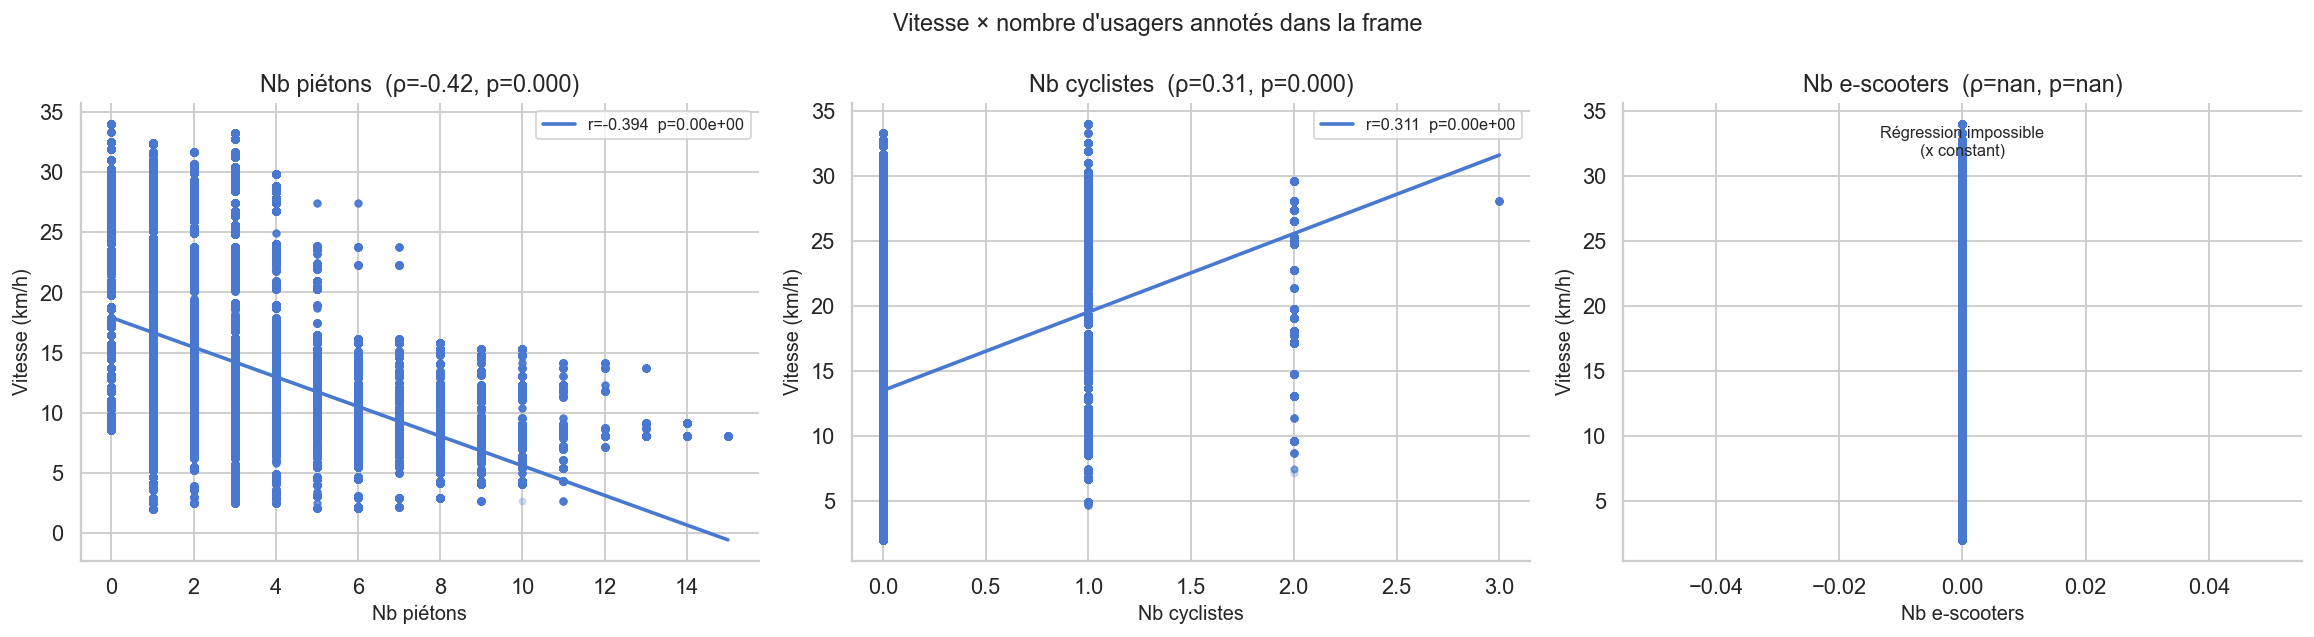

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


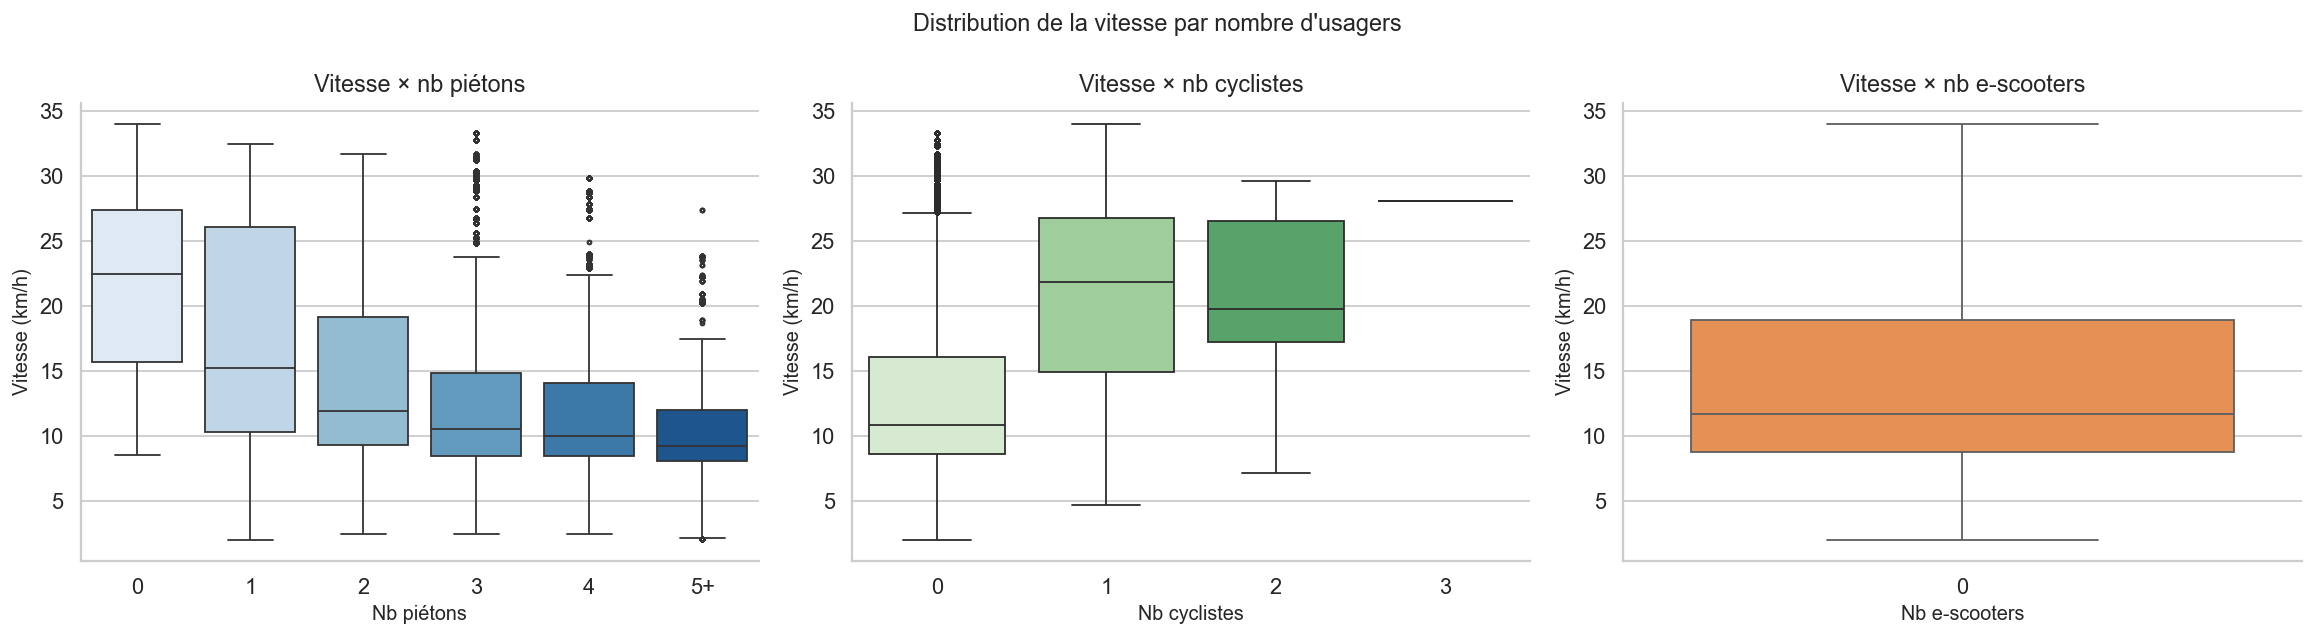

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:59: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(sub["x"], sub["y"])


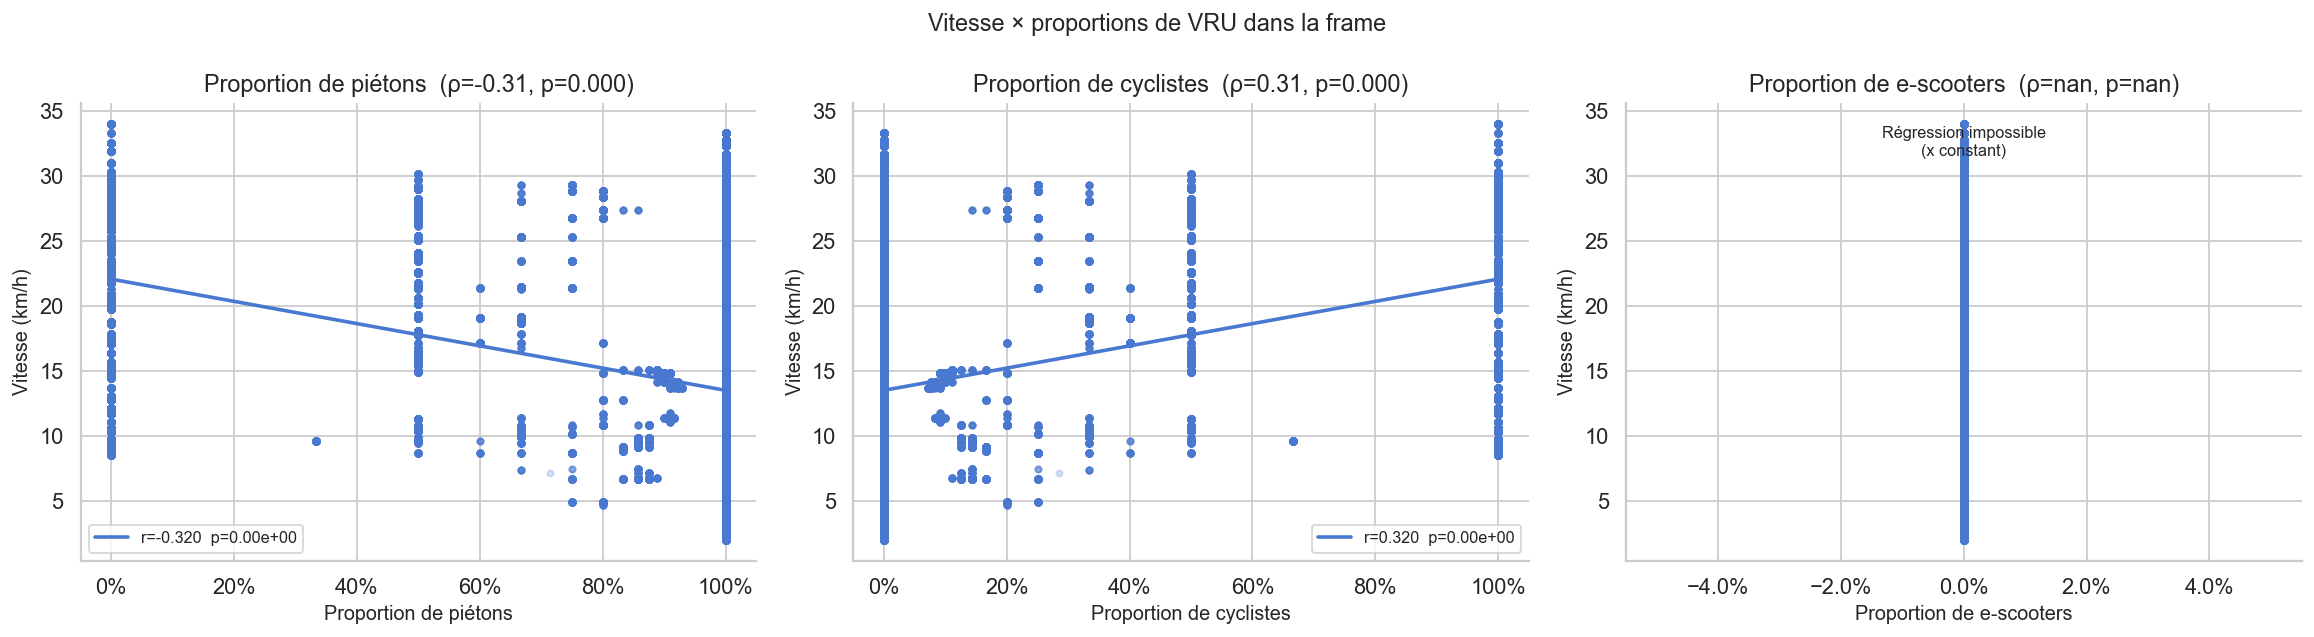

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:241: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

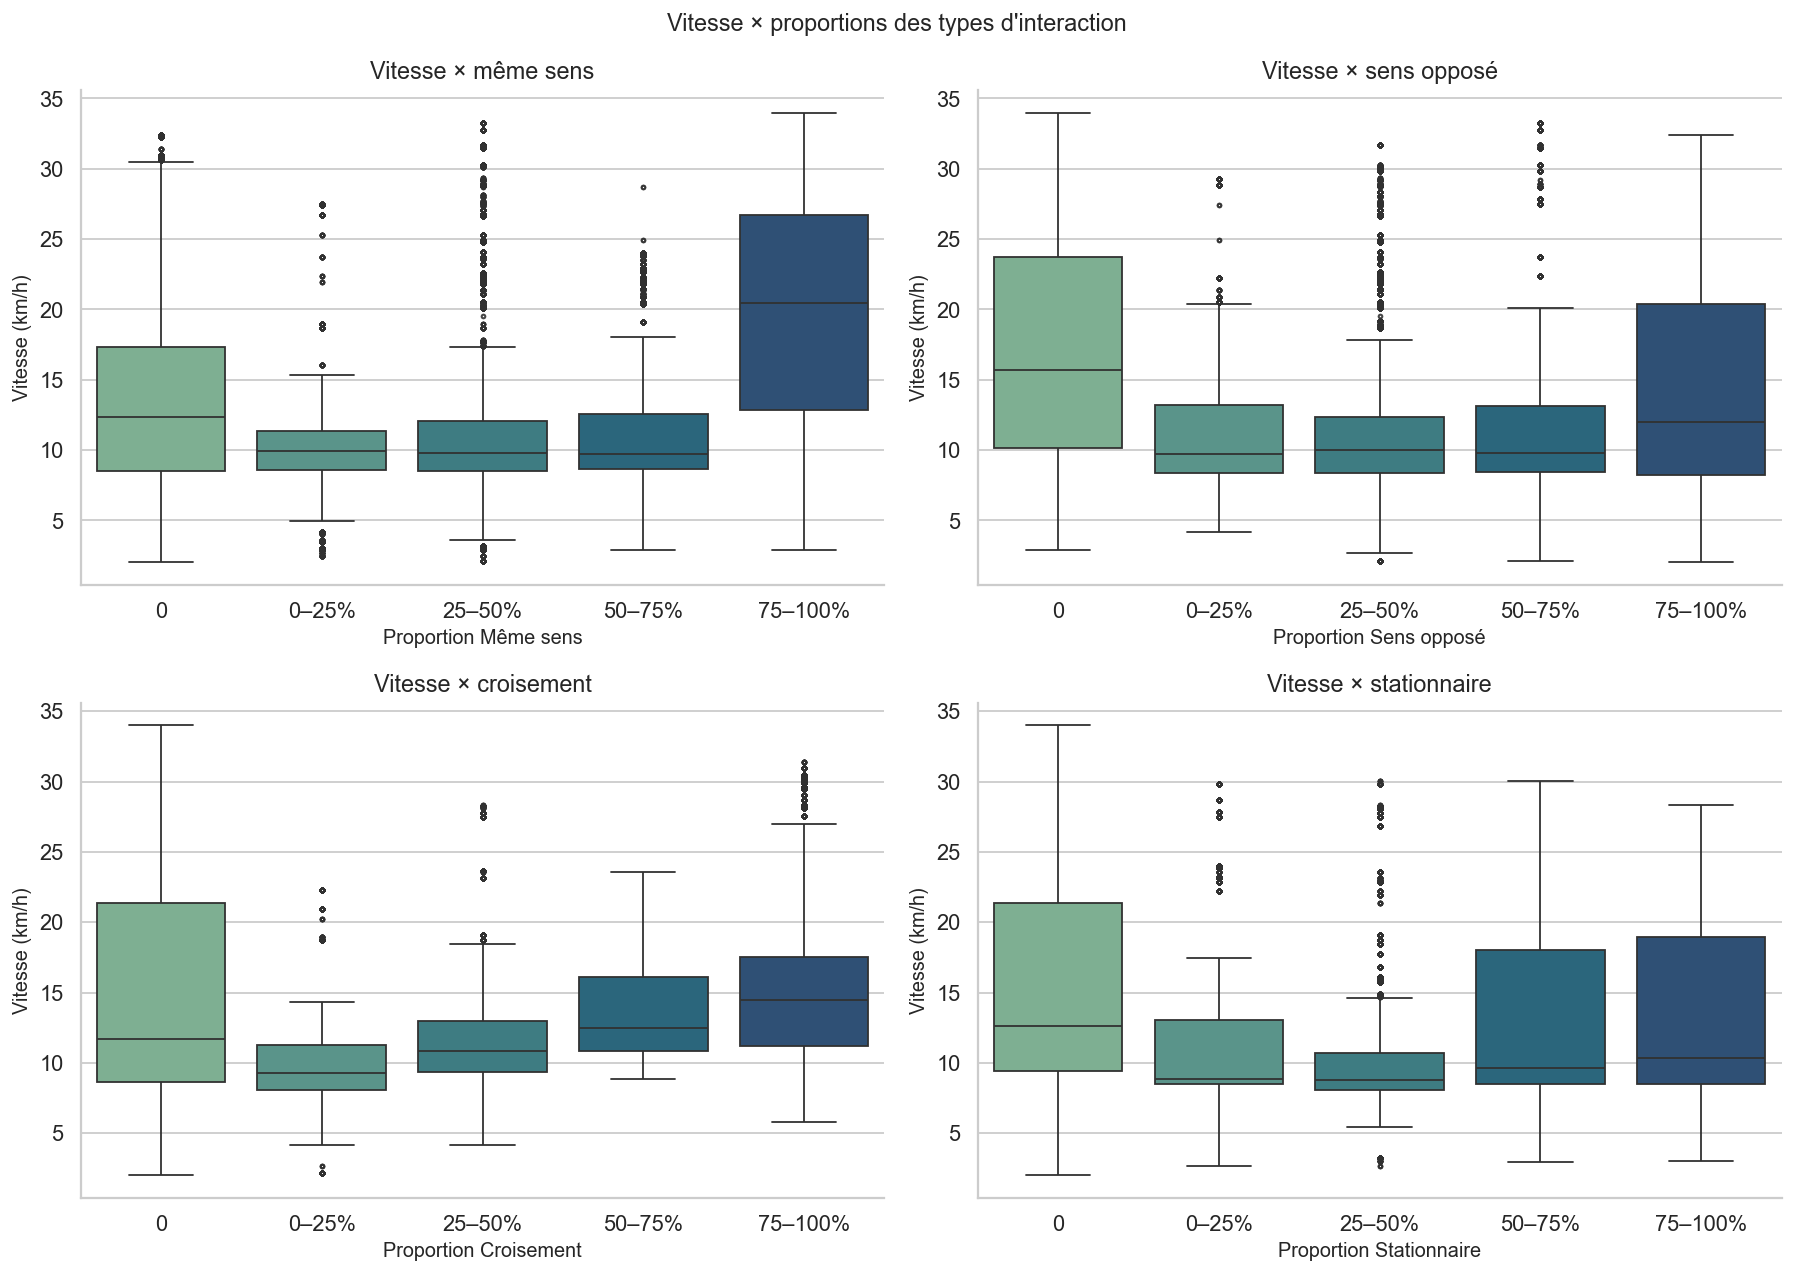

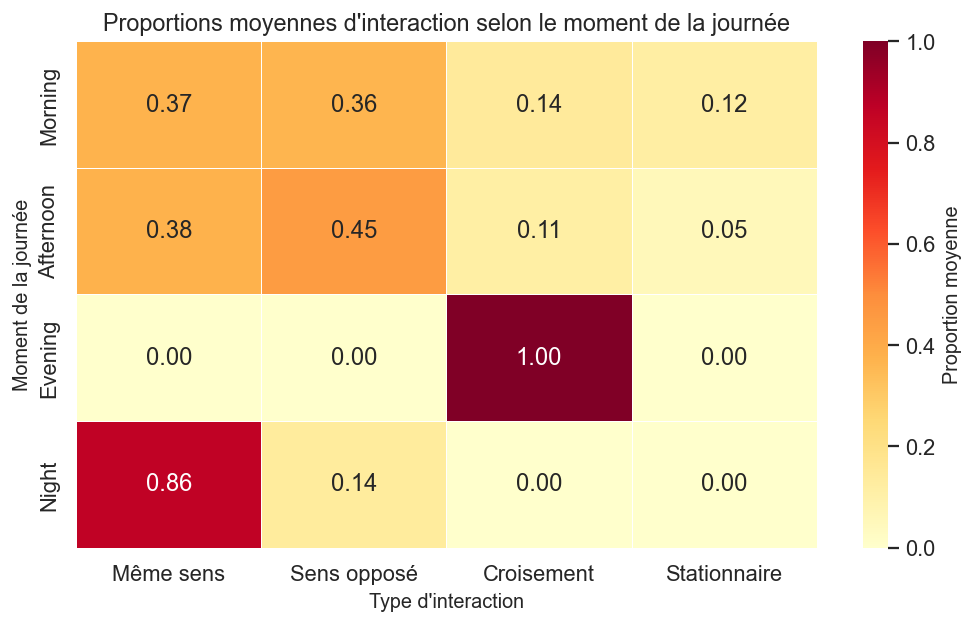

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:320: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:320: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:320: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


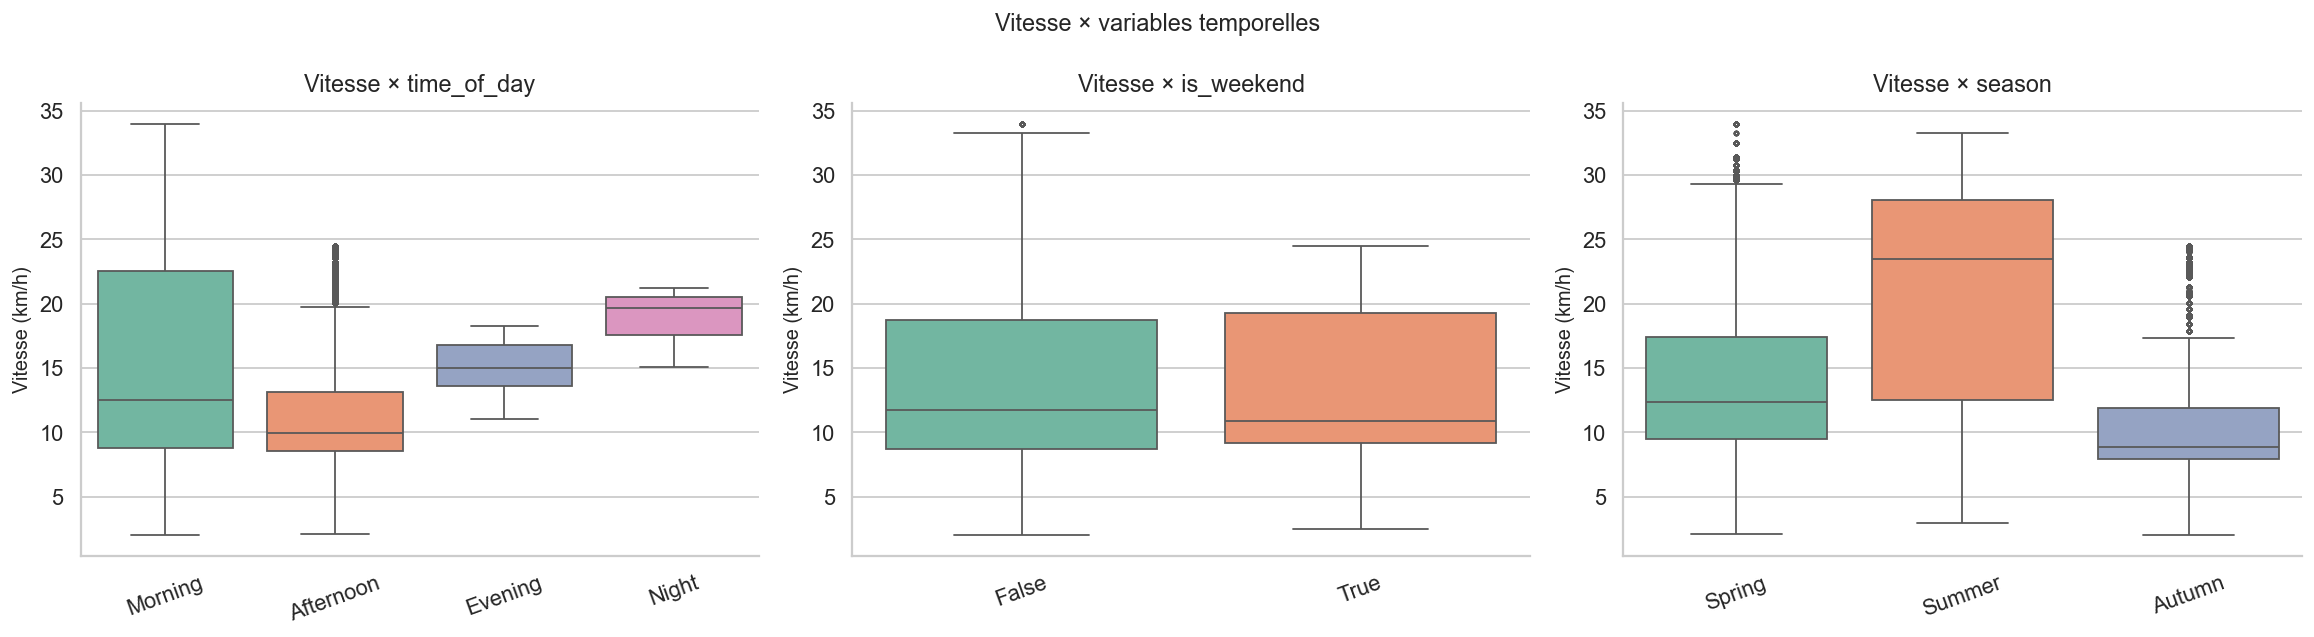


Tests statistiques — Vitesse × nombres et proportions

Variable                                       ρ speed     p speed
-------------------------------------------------------------------------------------
  Nb piétons                                -0.425 ***      0.0000
  Nb cyclistes                              +0.307 ***      0.0000
  Nb e-scooters                                +nan ns         nan
  Prop. piétons                             -0.309 ***      0.0000
  Prop. cyclistes                           +0.309 ***      0.0000
  Prop. e-scooters                             +nan ns         nan
  Prop. même sens                           +0.168 ***      0.0000
  Prop. sens opposé                         -0.228 ***      0.0000
  Prop. croisement                          +0.009 ***      0.0000
  Prop. stationnaire                        -0.241 ***      0.0000

Variable                                  ρ road_width           p
-----------------------------------------------------

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(sub["x"], sub["y"])
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(sub["x"], sub["y"])
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(sub["x"], sub["y"])
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/1132863846.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(sub["x"], sub["y"])


  Prop. piétons                             +0.119 ***      0.0000
  Prop. cyclistes                           -0.119 ***      0.0000
  Prop. e-scooters                             +nan ns         nan
  Prop. même sens                           +0.062 ***      0.0000
  Prop. sens opposé                         +0.056 ***      0.0000
  Prop. croisement                          -0.012 ***      0.0000
  Prop. stationnaire                        +0.073 ***      0.0000

Légende : *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05
Tests : corrélations de Spearman


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# Vitesse & distance × proportions de VRU / interactions
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Colonnes attendues ───────────────────────────────────────────────────────
REQ_COLS = [
    "speed_kmh",
    "n_pedestrians", "n_cyclists", "n_escooters",
    "prop_vru_pedestrian", "prop_vru_cyclist", "prop_vru_e_scooter",
    "prop_interaction_same_direction", "prop_interaction_opposite_direction",
    "prop_interaction_crossing", "prop_interaction_stationary",
]
missing = [c for c in REQ_COLS if c not in df.columns]
if missing:
    print(f"⚠ Colonnes manquantes : {missing}")
else:
    print("✔ Colonnes proportions présentes")

obs = df.copy()

# ── Nettoyage numérique ──────────────────────────────────────────────────────
num_cols = [
    "speed_kmh", "road_width_perp_m",
    "n_pedestrians", "n_cyclists", "n_escooters",
    "prop_vru_pedestrian", "prop_vru_cyclist", "prop_vru_e_scooter",
    "prop_interaction_same_direction", "prop_interaction_opposite_direction",
    "prop_interaction_crossing", "prop_interaction_stationary",
    "prop_interaction_unknown",
]
for col in num_cols:
    if col in obs.columns:
        obs[col] = pd.to_numeric(obs[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Si tu n'as pas de distance_smooth_m dans le nouveau dataset,
# on utilise road_width_perp_m comme variable secondaire.
SECOND_Y = "road_width_perp_m" if "road_width_perp_m" in obs.columns else None

print(f"\nObservations totales : {len(obs)}")
for col in num_cols:
    if col in obs.columns:
        print(f"{col:35s}: {obs[col].notna().sum()} non nulles")


# ══════════════════════════════════════════════════════════════════════════════
# Helpers statistiques
# ══════════════════════════════════════════════════════════════════════════════

def spearman_title(x, y, base_title):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return f"{base_title}  (n={len(sub)}, insuf.)"
    r, p = stats.spearmanr(sub["x"], sub["y"])
    return f"{base_title}  (ρ={r:.2f}, p={p:.3f})"

def run_spearman(x, y):
    sub = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(sub) < 2:
        return None
    r, p = stats.spearmanr(sub["x"], sub["y"])
    sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
    return r, p, sig

def run_kruskal(data, group_col, val_col):
    groups = [g[val_col].dropna().values
              for _, g in data.dropna(subset=[group_col, val_col]).groupby(group_col)]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        return None
    stat, p = stats.kruskal(*groups)
    sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
    return stat, p, sig

def make_prop_bins(series):
    """
    Bins lisibles pour proportions [0,1].
    """
    s = pd.to_numeric(series, errors="coerce")
    return pd.cut(
        s,
        bins=[-0.001, 0, 0.25, 0.50, 0.75, 1.0],
        labels=["0", "0–25%", "25–50%", "50–75%", "75–100%"]
    )


# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Scatter vitesse × nombre d'usagers par frame
# ══════════════════════════════════════════════════════════════════════════════

count_vars = [
    ("n_pedestrians", "Nb piétons", "Blues"),
    ("n_cyclists", "Nb cyclistes", "Greens"),
    ("n_escooters", "Nb e-scooters", "Oranges"),
]

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Vitesse × nombre d'usagers annotés dans la frame", fontsize=13)

for ax, (xcol, xlabel, pal) in zip(axes1, count_vars):
    if xcol not in obs.columns:
        ax.set_visible(False)
        continue

    sub = obs[[xcol, "speed_kmh"]].dropna()
    ax.scatter(sub[xcol], sub["speed_kmh"], alpha=0.22, s=12)

    if len(sub) >= 2 and sub[xcol].nunique() >= 2:
        m, b, r, p, se = stats.linregress(sub[xcol], sub["speed_kmh"])
        x_line = np.linspace(sub[xcol].min(), sub[xcol].max(), 200)
        ax.plot(x_line, m * x_line + b, lw=2, label=f"r={r:.3f}  p={p:.2e}")
        ax.legend(fontsize=9)
    else:
        ax.text(
            0.5, 0.95,
            "Régression impossible\n(x constant)",
            transform=ax.transAxes,
            ha="center", va="top",
        fontsize=9
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Vitesse (km/h)")
    ax.set_title(spearman_title(sub[xcol], sub["speed_kmh"], xlabel))

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Boxplots vitesse × nombre d'usagers
# ══════════════════════════════════════════════════════════════════════════════

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Distribution de la vitesse par nombre d'usagers", fontsize=13)

for ax, (xcol, xlabel, pal) in zip(axes2, count_vars):
    if xcol not in obs.columns:
        ax.set_visible(False)
        continue

    sub = obs[[xcol, "speed_kmh"]].dropna().copy()
    sub[f"{xcol}_cat"] = sub[xcol].clip(upper=5).astype(int).astype(str)
    sub[f"{xcol}_cat"] = sub[f"{xcol}_cat"].replace({"5": "5+"})

    order = [str(i) for i in range(0, 5)] + ["5+"]
    order = [o for o in order if o in sub[f"{xcol}_cat"].unique()]

    sns.boxplot(
        data=sub,
        x=f"{xcol}_cat",
        y="speed_kmh",
        order=order,
        palette=pal,
        ax=ax,
        flierprops={"markersize": 2, "alpha": 0.3}
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Vitesse (km/h)")
    ax.set_title(f"Vitesse × {xlabel.lower()}")

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — Vitesse × proportions de VRU
# ══════════════════════════════════════════════════════════════════════════════

vru_prop_vars = [
    ("prop_vru_pedestrian", "Proportion de piétons"),
    ("prop_vru_cyclist", "Proportion de cyclistes"),
    ("prop_vru_e_scooter", "Proportion de e-scooters"),
]

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle("Vitesse × proportions de VRU dans la frame", fontsize=13)

for ax, (xcol, xlabel) in zip(axes3, vru_prop_vars):
    if xcol not in obs.columns:
        ax.set_visible(False)
        continue

    sub = obs[[xcol, "speed_kmh"]].dropna()

    ax.scatter(sub[xcol], sub["speed_kmh"], alpha=0.22, s=12)

    if len(sub) >= 2 and sub[xcol].nunique() >= 2:
        m, b, r, p, se = stats.linregress(sub[xcol], sub["speed_kmh"])
        x_line = np.linspace(sub[xcol].min(), sub[xcol].max(), 200)
        ax.plot(x_line, m * x_line + b, lw=2, label=f"r={r:.3f}  p={p:.2e}")
        ax.legend(fontsize=9)
    else:
        ax.text(
            0.5, 0.95,
            "Régression impossible\n(x constant)",
            transform=ax.transAxes,
            ha="center", va="top",
            fontsize=9
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Vitesse (km/h)")
    ax.set_title(spearman_title(sub[xcol], sub["speed_kmh"], xlabel))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Figure 4 — Boxplots vitesse × proportions d'interaction
# ══════════════════════════════════════════════════════════════════════════════

interaction_prop_vars = [
    ("prop_interaction_same_direction", "Même sens"),
    ("prop_interaction_opposite_direction", "Sens opposé"),
    ("prop_interaction_crossing", "Croisement"),
    ("prop_interaction_stationary", "Stationnaire"),
]

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))
fig4.suptitle("Vitesse × proportions des types d'interaction", fontsize=13)

for ax, (xcol, xlabel) in zip(axes4.ravel(), interaction_prop_vars):
    if xcol not in obs.columns:
        ax.set_visible(False)
        continue

    sub = obs[[xcol, "speed_kmh"]].dropna().copy()
    sub["prop_bin"] = make_prop_bins(sub[xcol])

    order = ["0", "0–25%", "25–50%", "50–75%", "75–100%"]
    order = [o for o in order if o in sub["prop_bin"].astype(str).unique()]

    sns.boxplot(
        data=sub,
        x="prop_bin",
        y="speed_kmh",
        order=order,
        palette="crest",
        ax=ax,
        flierprops={"markersize": 2, "alpha": 0.3}
    )
    ax.set_xlabel(f"Proportion {xlabel}")
    ax.set_ylabel("Vitesse (km/h)")
    ax.set_title(f"Vitesse × {xlabel.lower()}")

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Figure 5 — Heatmap des proportions moyennes d'interaction par moment
# ══════════════════════════════════════════════════════════════════════════════

if "time_of_day" in obs.columns:
    heat_cols = [
        "prop_interaction_same_direction",
        "prop_interaction_opposite_direction",
        "prop_interaction_crossing",
        "prop_interaction_stationary",
    ]
    heat_cols = [c for c in heat_cols if c in obs.columns]

    if heat_cols:
        hm = (
            obs.groupby("time_of_day")[heat_cols]
            .mean()
            .reindex(["Morning", "Afternoon", "Evening", "Night"])
        )
        hm.columns = ["Même sens", "Sens opposé", "Croisement", "Stationnaire"][:len(hm.columns)]

        plt.figure(figsize=(8, 5))
        sns.heatmap(
            hm,
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            linewidths=0.3,
            cbar_kws={"label": "Proportion moyenne"}
        )
        plt.title("Proportions moyennes d'interaction selon le moment de la journée")
        plt.xlabel("Type d'interaction")
        plt.ylabel("Moment de la journée")
        plt.tight_layout()
        plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Figure 6 — Variables temporelles × vitesse
# ══════════════════════════════════════════════════════════════════════════════

temporal_available = [c for c in ["time_of_day", "is_weekend", "season"] if c in obs.columns]

if temporal_available:
    fig6, axes6 = plt.subplots(1, len(temporal_available), figsize=(6 * len(temporal_available), 5))
    if len(temporal_available) == 1:
        axes6 = [axes6]

    fig6.suptitle("Vitesse × variables temporelles", fontsize=13)

    for ax, col in zip(axes6, temporal_available):
        sub = obs[[col, "speed_kmh"]].dropna()

        if col == "time_of_day":
            order = [x for x in ["Morning", "Afternoon", "Evening", "Night"] if x in sub[col].unique()]
        elif col == "season":
            order = [x for x in ["Spring", "Summer", "Autumn", "Winter"] if x in sub[col].unique()]
        elif col == "is_weekend":
            order = [x for x in [False, True] if x in sub[col].unique()]
        else:
            order = sorted(sub[col].unique())

        sns.boxplot(
            data=sub,
            x=col,
            y="speed_kmh",
            order=order,
            palette="Set2",
            ax=ax,
            flierprops={"markersize": 2, "alpha": 0.3}
        )
        ax.set_title(f"Vitesse × {col}")
        ax.set_xlabel("")
        ax.set_ylabel("Vitesse (km/h)")
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Tableau de tests statistiques
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 85)
print("Tests statistiques — Vitesse × nombres et proportions")
print("=" * 85)

print(f"\n{'Variable':38s}  {'ρ speed':>14}  {'p speed':>10}")
print("-" * 85)

test_numeric_vars = [
    ("n_pedestrians", "Nb piétons"),
    ("n_cyclists", "Nb cyclistes"),
    ("n_escooters", "Nb e-scooters"),
    ("prop_vru_pedestrian", "Prop. piétons"),
    ("prop_vru_cyclist", "Prop. cyclistes"),
    ("prop_vru_e_scooter", "Prop. e-scooters"),
    ("prop_interaction_same_direction", "Prop. même sens"),
    ("prop_interaction_opposite_direction", "Prop. sens opposé"),
    ("prop_interaction_crossing", "Prop. croisement"),
    ("prop_interaction_stationary", "Prop. stationnaire"),
]

for col, label in test_numeric_vars:
    if col not in obs.columns:
        continue
    res = run_spearman(obs[col], obs["speed_kmh"])
    if res is None:
        print(f"  {label:36s}  {'n/a':>14}  {'—':>10}")
    else:
        r, p, sig = res
        print(f"  {label:36s}  {f'{r:+.3f} {sig}':>14}  {p:>10.4f}")

if SECOND_Y is not None:
    print(f"\n{'Variable':38s}  {'ρ ' + SECOND_Y[:10]:>14}  {'p':>10}")
    print("-" * 85)
    for col, label in test_numeric_vars:
        if col not in obs.columns:
            continue
        res = run_spearman(obs[col], obs[SECOND_Y])
        if res is None:
            print(f"  {label:36s}  {'n/a':>14}  {'—':>10}")
        else:
            r, p, sig = res
            print(f"  {label:36s}  {f'{r:+.3f} {sig}':>14}  {p:>10.4f}")

print("\nLégende : *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05")
print("Tests : corrélations de Spearman")

# For the paper

/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_97265/2493199855.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


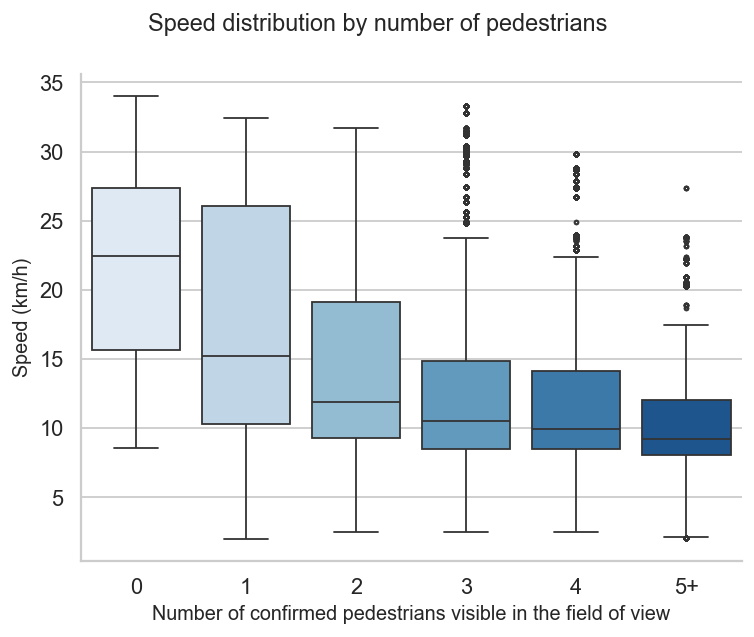

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Boxplot vitesse × nombre de piétons
# ══════════════════════════════════════════════════════════════════════════════

fig2, ax = plt.subplots(figsize=(6, 5))
fig2.suptitle("Speed distribution by number of pedestrians", fontsize=13)

xcol, xlabel, pal = count_vars[0]

if xcol in obs.columns:
    sub = obs[[xcol, "speed_kmh"]].dropna().copy()
    sub[f"{xcol}_cat"] = sub[xcol].clip(upper=5).astype(int).astype(str)
    sub[f"{xcol}_cat"] = sub[f"{xcol}_cat"].replace({"5": "5+"})

    order = [str(i) for i in range(0, 5)] + ["5+"]
    order = [o for o in order if o in sub[f"{xcol}_cat"].unique()]

    sns.boxplot(
        data=sub,
        x=f"{xcol}_cat",
        y="speed_kmh",
        order=order,
        palette=pal,
        ax=ax,
        flierprops={"markersize": 2, "alpha": 0.3}
    )

    ax.set_xlabel("Number of confirmed pedestrians visible in the field of view")
    ax.set_ylabel("Speed (km/h)")
    #ax.set_title(f"Speed vs {xlabel.lower()}")

plt.tight_layout()

# Sauvegarde PDF
fig2.savefig("/Volumes/My Passport/NEWMOB/boxplot_pedestrians_speed.png", dpi=300, bbox_inches="tight")

plt.show()